<a href="https://colab.research.google.com/github/sania934/EnergyMol-MLIP/blob/main/06_transferability_and_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
!pip install mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.5/457.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.9 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39523 sha256=4839cab5f9cea4f9206a21a061d2488a9e3b4f86554ddd92109375040ece90b1
  Stored in directory: /root/.cache/pip/wheels/05/2e/7e/39f980a5a0755f9faf3a612e1e2c9460500b864b94b06fb6fb
Successfully built python-hostlist


In [ ]:
# ============================================================
# CELL 1 — PROJECT AND DATASET SETUP
# ============================================================

from pathlib import Path
import json
import os
import pandas as pd
import numpy as np

print("=" * 70)
print("ENERGYMOL-MLIP — TRANSFERABILITY AND LEARNING CURVES")
print("=" * 70)

# ------------------------------------------------------------
# IMPORTANT:
# Google Drive is already mounted in this Colab runtime.
# Do NOT call drive.mount() again.
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

print()
print("Project directory:")
print(PROJECT_DIR)

# ------------------------------------------------------------
# Locate processed-data directory
# ------------------------------------------------------------

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print()
print("Checking processed-data directory:")
print(PROCESSED_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        "The Google Drive project path is not available in "
        "this runtime.\n\n"
        "Please check that Google Drive is mounted in Colab "
        "before continuing."
    )

# ------------------------------------------------------------
# Show actual files
# ------------------------------------------------------------

print()
print("Available processed-data files:")
print("-" * 70)

for file_path in sorted(PROCESSED_DIR.iterdir()):
    print(file_path.name)

# ------------------------------------------------------------
# Select the validated MACE split files
# ------------------------------------------------------------

MACE0316_TRAIN = (
    PROCESSED_DIR /
    "mace_train_mace0316.extxyz"
)

MACE0316_VALID = (
    PROCESSED_DIR /
    "mace_validation_mace0316.extxyz"
)

MACE0316_TRANSFER = (
    PROCESSED_DIR /
    "mace_test_transfer_mace0316.extxyz"
)

ORIGINAL_TRAIN = (
    PROCESSED_DIR /
    "mace_train.extxyz"
)

ORIGINAL_VALID = (
    PROCESSED_DIR /
    "mace_validation.extxyz"
)

ORIGINAL_TRANSFER = (
    PROCESSED_DIR /
    "mace_test_transfer.extxyz"
)

# Prefer the MACE 0.3.16-compatible files.
# Fall back to the validated original files only if needed.

TRAIN_FILE = (
    MACE0316_TRAIN
    if MACE0316_TRAIN.exists()
    else ORIGINAL_TRAIN
)

VALID_FILE = (
    MACE0316_VALID
    if MACE0316_VALID.exists()
    else ORIGINAL_VALID
)

TRANSFER_FILE = (
    MACE0316_TRANSFER
    if MACE0316_TRANSFER.exists()
    else ORIGINAL_TRANSFER
)

SPLIT_FILE = PROCESSED_DIR / "molecule_split.csv"

# ------------------------------------------------------------
# Verify selected files
# ------------------------------------------------------------

print()
print("Selected input files:")
print("Training      :", TRAIN_FILE)
print("Validation    :", VALID_FILE)
print("Transfer test :", TRANSFER_FILE)
print("Molecule split:", SPLIT_FILE)

print()
print("File availability:")

for label, file_path in [
    ("Training", TRAIN_FILE),
    ("Validation", VALID_FILE),
    ("Transfer test", TRANSFER_FILE),
    ("Molecule split", SPLIT_FILE),
]:
    print(
        f"{label:<16}: "
        f"{file_path.exists()}"
    )

required_files = [
    TRAIN_FILE,
    VALID_FILE,
    TRANSFER_FILE,
    SPLIT_FILE,
]

if not all(file_path.exists() for file_path in required_files):
    raise FileNotFoundError(
        "One or more required MLIP dataset files are missing. "
        "The printed file list above shows what is actually "
        "available."
    )

print()
print("All required input files found.")

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

LEARNING_DIR = (
    PROJECT_DIR /
    "results" /
    "learning_curves"
)

LEARNING_DATA_DIR = (
    LEARNING_DIR /
    "datasets"
)

LEARNING_MODEL_DIR = (
    LEARNING_DIR /
    "models"
)

LEARNING_METRICS_DIR = (
    LEARNING_DIR /
    "metrics"
)

LEARNING_FIGURES_DIR = (
    LEARNING_DIR /
    "figures"
)

for directory in [
    LEARNING_DIR,
    LEARNING_DATA_DIR,
    LEARNING_MODEL_DIR,
    LEARNING_METRICS_DIR,
    LEARNING_FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print()
print("Output directories:")
print("Learning root  :", LEARNING_DIR)
print("Datasets       :", LEARNING_DATA_DIR)
print("Models         :", LEARNING_MODEL_DIR)
print("Metrics        :", LEARNING_METRICS_DIR)
print("Figures        :", LEARNING_FIGURES_DIR)

# ------------------------------------------------------------
# Frozen experiment settings
# ------------------------------------------------------------

SEED = 123

LEARNING_SIZES = [
    93,
    186,
    279,
    372,
]

VALIDATION_SIZE = 96
TRANSFER_SIZE = 95

print()
print("Frozen learning-curve design:")
print("Training sizes :", LEARNING_SIZES)
print("Validation     :", VALIDATION_SIZE)
print("Transfer test  :", TRANSFER_SIZE)
print("Random seed    :", SEED)

print()
print("=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — TRANSFERABILITY AND LEARNING CURVES

Project directory:
/content/drive/MyDrive/MLIP project

Checking processed-data directory:
/content/drive/MyDrive/MLIP project/data/processed

Available processed-data files:
----------------------------------------------------------------------
configuration_generation_summary.txt
configuration_manifest.csv
dft_dataset.extxyz
dft_dataset_mace.extxyz
dft_dataset_manifest.csv
dft_dataset_qc.csv
dft_full_manifest.csv
dft_pilot_manifest.csv
dft_results_raw.csv
mace
mace_test_transfer.extxyz
mace_train.extxyz
mace_validation.extxyz
molecule_split.csv

Selected input files:
Training      : /content/drive/MyDrive/MLIP project/data/processed/mace_train.extxyz
Validation    : /content/drive/MyDrive/MLIP project/data/processed/mace_validation.extxyz
Transfer test : /content/drive/MyDrive/MLIP project/data/processed/mace_test_transfer.extxyz
Molecule split: /content/drive/MyDrive/MLIP project/data/processed/molecule_split.csv

File availabili

In [4]:
# ============================================================
# CELL 2A — INSTALL/VERIFY ASE
# ============================================================

import sys
import subprocess

print("=" * 70)
print("CELL 2A — INSTALL/VERIFY ASE")
print("=" * 70)

try:
    import ase

    print()
    print("ASE is already installed.")
    print("ASE version:", ase.__version__)

except ImportError:

    print()
    print("ASE not found. Installing...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "ase"
    ])

    import ase

    print()
    print("ASE installation completed.")
    print("ASE version:", ase.__version__)

print()
print("=" * 70)
print("CELL 2A COMPLETE")
print("=" * 70)

CELL 2A — INSTALL/VERIFY ASE

ASE not found. Installing...

ASE installation completed.
ASE version: 3.29.0

CELL 2A COMPLETE


In [ ]:
# ============================================================
# CELL 2 — LOAD AND VALIDATE FIXED DATASETS
# ============================================================

from ase.io import read
import numpy as np
import pandas as pd

print("=" * 70)
print("CELL 2 — LOAD AND VALIDATE FIXED DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

train_atoms = read(TRAIN_FILE, index=":")
validation_atoms = read(VALID_FILE, index=":")
transfer_atoms = read(TRANSFER_FILE, index=":")

print()
print("Datasets loaded successfully.")

print()
print("Configuration counts:")
print(f"Training      : {len(train_atoms)}")
print(f"Validation    : {len(validation_atoms)}")
print(f"Transfer test : {len(transfer_atoms)}")

# ------------------------------------------------------------
# Basic count checks
# ------------------------------------------------------------

assert len(train_atoms) == 372, (
    f"Expected 372 training configurations, "
    f"found {len(train_atoms)}"
)

assert len(validation_atoms) == 96, (
    f"Expected 96 validation configurations, "
    f"found {len(validation_atoms)}"
)

assert len(transfer_atoms) == 95, (
    f"Expected 95 transfer configurations, "
    f"found {len(transfer_atoms)}"
)

# ------------------------------------------------------------
# Check MACE reference labels
# ------------------------------------------------------------

def validate_mace_labels(dataset, dataset_name):

    for i, atoms in enumerate(dataset):

        assert "REF_energy" in atoms.info, (
            f"{dataset_name}: missing REF_energy "
            f"at configuration {i}"
        )

        assert "REF_forces" in atoms.arrays, (
            f"{dataset_name}: missing REF_forces "
            f"at configuration {i}"
        )

        energy = float(atoms.info["REF_energy"])
        forces = np.asarray(
            atoms.arrays["REF_forces"],
            dtype=float
        )

        assert np.isfinite(energy), (
            f"{dataset_name}: non-finite energy "
            f"at configuration {i}"
        )

        assert forces.shape == (len(atoms), 3), (
            f"{dataset_name}: incorrect force shape "
            f"at configuration {i}: {forces.shape}"
        )

        assert np.all(np.isfinite(forces)), (
            f"{dataset_name}: non-finite forces "
            f"at configuration {i}"
        )


validate_mace_labels(
    train_atoms,
    "Training"
)

validate_mace_labels(
    validation_atoms,
    "Validation"
)

validate_mace_labels(
    transfer_atoms,
    "Transfer"
)

print()
print("All REF_energy and REF_forces labels are valid.")

# ------------------------------------------------------------
# Check molecule IDs
# ------------------------------------------------------------

def get_molecule_ids(dataset):
    return sorted(
        set(
            str(atoms.info["molecule_id"])
            for atoms in dataset
        )
    )

train_molecules = get_molecule_ids(train_atoms)
validation_molecules = get_molecule_ids(validation_atoms)
transfer_molecules = get_molecule_ids(transfer_atoms)

print()
print("Molecules represented:")
print("Training      :", train_molecules)
print("Validation    :", validation_molecules)
print("Transfer test :", transfer_molecules)

# ------------------------------------------------------------
# Verify no molecule leakage
# ------------------------------------------------------------

assert set(train_molecules).isdisjoint(
    set(validation_molecules)
)

assert set(train_molecules).isdisjoint(
    set(transfer_molecules)
)

assert set(validation_molecules).isdisjoint(
    set(transfer_molecules)
)

print()
print("No molecule leakage detected.")

# ------------------------------------------------------------
# Check configuration IDs
# ------------------------------------------------------------

def get_configuration_ids(dataset):
    return [
        str(atoms.info["configuration_id"])
        for atoms in dataset
    ]

train_ids = get_configuration_ids(train_atoms)
validation_ids = get_configuration_ids(validation_atoms)
transfer_ids = get_configuration_ids(transfer_atoms)

all_ids = (
    train_ids +
    validation_ids +
    transfer_ids
)

assert len(all_ids) == len(set(all_ids)), (
    "Duplicate configuration IDs detected."
)

print()
print("All configuration IDs are unique.")

# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Transfer test"
    ],
    "Configurations": [
        len(train_atoms),
        len(validation_atoms),
        len(transfer_atoms)
    ],
    "Molecules": [
        len(train_molecules),
        len(validation_molecules),
        len(transfer_molecules)
    ],
})

print()
print("Dataset summary:")
display(summary)

# ------------------------------------------------------------
# Freeze datasets for this notebook
# ------------------------------------------------------------

print()
print("The validation and transfer datasets will remain")
print("FIXED and UNTOUCHED for all learning-curve models.")

print()
print("=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

CELL 2 — LOAD AND VALIDATE FIXED DATASETS

Datasets loaded successfully.

Configuration counts:
Training      : 372
Validation    : 96
Transfer test : 95


AssertionError: Training: missing REF_energy at configuration 0

In [6]:
# ============================================================
# CELL 2.5 — LOAD MACE TRAINING CONFIGURATIONS
# ============================================================

from pathlib import Path
from ase.io import read

print("=" * 70)
print("CELL 2.5 — LOAD MACE TRAINING CONFIGURATIONS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FILE = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace_train.extxyz"
)

assert TRAIN_FILE.exists(), (
    f"Training file not found:\n{TRAIN_FILE}"
)

# ------------------------------------------------------------
# Load all training configurations
# ------------------------------------------------------------

train_atoms = read(
    TRAIN_FILE,
    index=":"
)

print()
print("Training file:")
print(TRAIN_FILE)

print()
print("Training configurations:", len(train_atoms))

# ------------------------------------------------------------
# Check expected training-set size
# ------------------------------------------------------------

assert len(train_atoms) == 372, (
    f"Expected 372 training configurations, "
    f"found {len(train_atoms)}"
)

print(
    "372-configuration training set check: PASSED"
)

# ------------------------------------------------------------
# Check required metadata
# ------------------------------------------------------------

required_info = [
    "molecule_id",
    "configuration_id"
]

for key in required_info:

    missing = [
        i
        for i, atoms in enumerate(train_atoms)
        if key not in atoms.info
    ]

    assert not missing, (
        f"Missing atoms.info['{key}'] "
        f"in configurations: {missing[:10]}"
    )

print()
print("Required metadata check: PASSED")

# ------------------------------------------------------------
# Show molecule count
# ------------------------------------------------------------

molecule_ids = sorted({
    str(atoms.info["molecule_id"])
    for atoms in train_atoms
})

print()
print("Training molecules:", len(molecule_ids))
print("Molecule IDs:", molecule_ids)

assert len(molecule_ids) == 16, (
    f"Expected 16 training molecules, "
    f"found {len(molecule_ids)}"
)

print()
print("16-molecule training-set check: PASSED")

print()
print("=" * 70)
print("CELL 2.5 COMPLETE")
print("=" * 70)

CELL 2.5 — LOAD MACE TRAINING CONFIGURATIONS

Training file:
/content/drive/MyDrive/MLIP project/data/processed/mace_train.extxyz

Training configurations: 372
372-configuration training set check: PASSED

Required metadata check: PASSED

Training molecules: 16
Molecule IDs: ['M03', 'M04', 'M05', 'M07', 'M08', 'M10', 'M11', 'M12', 'M13', 'M15', 'M17', 'M18', 'M19', 'M20', 'M21', 'M22']

16-molecule training-set check: PASSED

CELL 2.5 COMPLETE


In [9]:
# ============================================================
# CELL 3 — DEFINE LEARNING-CURVE SAMPLING STRATEGY
# ============================================================

from collections import defaultdict
import random
import pandas as pd
import json

print("=" * 70)
print("CELL 3 — LEARNING-CURVE SAMPLING STRATEGY")
print("=" * 70)

# ------------------------------------------------------------
# Frozen settings
# ------------------------------------------------------------

LEARNING_SIZES = [93, 186, 279, 372]
SEED = 123

print()
print("Training sizes:", LEARNING_SIZES)
print("Random seed   :", SEED)

# ------------------------------------------------------------
# Group training configurations by molecule
# ------------------------------------------------------------

molecule_groups = defaultdict(list)

for index, atoms in enumerate(train_atoms):

    molecule_id = str(
        atoms.info["molecule_id"]
    )

    molecule_groups[molecule_id].append(index)

# ------------------------------------------------------------
# Sort molecules for deterministic ordering
# ------------------------------------------------------------

for molecule_id in molecule_groups:
    molecule_groups[molecule_id] = sorted(
        molecule_groups[molecule_id],
        key=lambda idx: str(
            train_atoms[idx].info["configuration_id"]
        )
    )

molecule_ids = sorted(molecule_groups.keys())

print()
print("Training molecules:")
for molecule_id in molecule_ids:
    print(
        f"{molecule_id}: "
        f"{len(molecule_groups[molecule_id])} configurations"
    )

print()
print("Number of training molecules:", len(molecule_ids))

assert len(molecule_ids) == 16, (
    f"Expected 16 training molecules, "
    f"found {len(molecule_ids)}"
)

# ------------------------------------------------------------
# Create deterministic shuffled configuration order
# ------------------------------------------------------------

rng = random.Random(SEED)

sampling_order = {}

for molecule_id in molecule_ids:

    indices = molecule_groups[molecule_id].copy()

    rng.shuffle(indices)

    sampling_order[molecule_id] = indices

# ------------------------------------------------------------
# Balanced round-robin sampling function
# ------------------------------------------------------------

def build_learning_subset(target_size):

    selected = []

    # Round-robin through molecules
    # until the requested number is reached.

    position = 0

    while len(selected) < target_size:

        added_this_round = False

        for molecule_id in molecule_ids:

            indices = sampling_order[molecule_id]

            if position < len(indices):

                selected.append(
                    indices[position]
                )

                added_this_round = True

                if len(selected) == target_size:
                    break

        if not added_this_round:
            break

        position += 1

    # Safety check
    if len(selected) != target_size:
        raise RuntimeError(
            f"Could not construct requested subset "
            f"of {target_size} configurations."
        )

    return selected

# ------------------------------------------------------------
# Construct all learning-curve subsets
# ------------------------------------------------------------

learning_indices = {}

for size in LEARNING_SIZES:

    indices = build_learning_subset(size)

    learning_indices[size] = indices

    print()
    print(
        f"Training subset {size}: "
        f"{len(indices)} configurations"
    )

# ------------------------------------------------------------
# Verify nesting
# ------------------------------------------------------------

for smaller, larger in zip(
    LEARNING_SIZES[:-1],
    LEARNING_SIZES[1:]
):

    smaller_set = set(
        learning_indices[smaller]
    )

    larger_set = set(
        learning_indices[larger]
    )

    assert smaller_set.issubset(
        larger_set
    ), (
        f"Learning subsets are not nested: "
        f"{smaller} -> {larger}"
    )

print()
print("Nested-subset check: PASSED")

# ------------------------------------------------------------
# Verify complete training set
# ------------------------------------------------------------

assert set(
    learning_indices[372]
) == set(range(len(train_atoms)))

print(
    "372-configuration subset matches "
    "the complete training set: PASSED"
)

# ------------------------------------------------------------
# Show molecule distribution
# ------------------------------------------------------------

distribution_rows = []

for size in LEARNING_SIZES:

    counts = defaultdict(int)

    for idx in learning_indices[size]:

        molecule_id = str(
            train_atoms[idx].info["molecule_id"]
        )

        counts[molecule_id] += 1

    for molecule_id in molecule_ids:

        distribution_rows.append({
            "Training size": size,
            "Molecule": molecule_id,
            "Configurations": counts[molecule_id]
        })

distribution_df = pd.DataFrame(
    distribution_rows
)

print()
print("Learning-curve molecule distribution:")

display(
    distribution_df.pivot(
        index="Molecule",
        columns="Training size",
        values="Configurations"
    ).fillna(0).astype(int)
)

# ------------------------------------------------------------
# Store sampling indices for later cells
# ------------------------------------------------------------

# ------------------------------------------------------------
# Define learning-curve output directory
# ------------------------------------------------------------

LEARNING_DATA_DIR = (
    PROJECT_DIR /
    "results" /
    "learning_curve"
)

LEARNING_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAMPLING_FILE = (
    LEARNING_DATA_DIR /
    "learning_curve_sampling_indices.json"
)

sampling_json = {
    str(size): [
        int(idx)
        for idx in learning_indices[size]
    ]
    for size in LEARNING_SIZES
}

with open(SAMPLING_FILE, "w") as f:
    json.dump(
        sampling_json,
        f,
        indent=2
    )

print()
print("Sampling definition saved:")
print(SAMPLING_FILE)

print()
print("=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

CELL 3 — LEARNING-CURVE SAMPLING STRATEGY

Training sizes: [93, 186, 279, 372]
Random seed   : 123

Training molecules:
M03: 24 configurations
M04: 24 configurations
M05: 22 configurations
M07: 18 configurations
M08: 20 configurations
M10: 24 configurations
M11: 24 configurations
M12: 24 configurations
M13: 24 configurations
M15: 24 configurations
M17: 24 configurations
M18: 24 configurations
M19: 24 configurations
M20: 24 configurations
M21: 24 configurations
M22: 24 configurations

Number of training molecules: 16

Training subset 93: 93 configurations

Training subset 186: 186 configurations

Training subset 279: 279 configurations

Training subset 372: 372 configurations

Nested-subset check: PASSED
372-configuration subset matches the complete training set: PASSED

Learning-curve molecule distribution:


Training size,93,186,279,372
Molecule,,,,
M03,6,12,18,24
M04,6,12,18,24
M05,6,12,18,22
M07,6,12,18,18
M08,6,12,18,20
M10,6,12,18,24
M11,6,12,18,24
M12,6,12,17,24
M13,6,12,17,24



Sampling definition saved:
/content/drive/MyDrive/MLIP project/results/learning_curve/learning_curve_sampling_indices.json

CELL 3 COMPLETE


In [10]:
# ============================================================
# CELL 4 — VERIFY LEARNING-CURVE SAMPLING DEFINITION
# ============================================================

from pathlib import Path
import json
from collections import Counter

print("=" * 70)
print("CELL 4 — VERIFY LEARNING-CURVE SAMPLING DEFINITION")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DATA_DIR = (
    PROJECT_DIR /
    "results" /
    "learning_curve"
)

SAMPLING_FILE = (
    LEARNING_DATA_DIR /
    "learning_curve_sampling_indices.json"
)

assert SAMPLING_FILE.exists(), (
    f"Sampling file not found:\n{SAMPLING_FILE}"
)

# ------------------------------------------------------------
# Load saved sampling indices
# ------------------------------------------------------------

with open(SAMPLING_FILE, "r") as f:
    saved_sampling = json.load(f)

expected_sizes = [93, 186, 279, 372]

assert sorted(
    int(key) for key in saved_sampling.keys()
) == expected_sizes, (
    "Saved sampling sizes do not match expected sizes."
)

print()
print("Saved sampling sizes:", expected_sizes)

# ------------------------------------------------------------
# Convert indices to sets
# ------------------------------------------------------------

sampling_sets = {
    int(size): set(indices)
    for size, indices in saved_sampling.items()
}

# ------------------------------------------------------------
# Check sizes
# ------------------------------------------------------------

for size in expected_sizes:

    actual_size = len(sampling_sets[size])

    assert actual_size == size, (
        f"Size mismatch for {size}: "
        f"expected {size}, found {actual_size}"
    )

    print(
        f"{size}-configuration subset size: PASSED"
    )

# ------------------------------------------------------------
# Check for duplicate indices
# ------------------------------------------------------------

for size in expected_sizes:

    raw_indices = saved_sampling[str(size)]

    assert len(raw_indices) == len(set(raw_indices)), (
        f"Duplicate configuration indices found "
        f"in subset {size}"
    )

print()
print("Duplicate-index check: PASSED")

# ------------------------------------------------------------
# Check nested structure
# ------------------------------------------------------------

for smaller, larger in zip(
    expected_sizes[:-1],
    expected_sizes[1:]
):

    assert sampling_sets[smaller].issubset(
        sampling_sets[larger]
    ), (
        f"Nested-subset check failed: "
        f"{smaller} is not contained in {larger}"
    )

    print(
        f"{smaller} ⊂ {larger}: PASSED"
    )

# ------------------------------------------------------------
# Check final subset covers all 372 training configurations
# ------------------------------------------------------------

assert sampling_sets[372] == set(
    range(len(train_atoms))
), (
    "372 subset does not match the complete training set."
)

print()
print(
    "372-subset complete-training-set check: PASSED"
)

# ------------------------------------------------------------
# Verify molecule distribution from saved indices
# ------------------------------------------------------------

print()
print("Molecule distribution from saved sampling:")

for size in expected_sizes:

    counts = Counter()

    for idx in sampling_sets[size]:

        molecule_id = str(
            train_atoms[idx].info["molecule_id"]
        )

        counts[molecule_id] += 1

    print()
    print(f"Training size {size}:")

    for molecule_id in sorted(counts):

        print(
            f"  {molecule_id}: "
            f"{counts[molecule_id]}"
        )

# ------------------------------------------------------------
# Verify all indices are valid
# ------------------------------------------------------------

for size in expected_sizes:

    invalid = [
        idx
        for idx in sampling_sets[size]
        if idx < 0 or idx >= len(train_atoms)
    ]

    assert not invalid, (
        f"Invalid indices found in subset {size}: "
        f"{invalid[:10]}"
    )

print()
print("Index-validity check: PASSED")

print()
print("=" * 70)
print("CELL 4 COMPLETE — SAMPLING VERIFIED")
print("=" * 70)

CELL 4 — VERIFY LEARNING-CURVE SAMPLING DEFINITION

Saved sampling sizes: [93, 186, 279, 372]
93-configuration subset size: PASSED
186-configuration subset size: PASSED
279-configuration subset size: PASSED
372-configuration subset size: PASSED

Duplicate-index check: PASSED
93 ⊂ 186: PASSED
186 ⊂ 279: PASSED
279 ⊂ 372: PASSED

372-subset complete-training-set check: PASSED

Molecule distribution from saved sampling:

Training size 93:
  M03: 6
  M04: 6
  M05: 6
  M07: 6
  M08: 6
  M10: 6
  M11: 6
  M12: 6
  M13: 6
  M15: 6
  M17: 6
  M18: 6
  M19: 6
  M20: 5
  M21: 5
  M22: 5

Training size 186:
  M03: 12
  M04: 12
  M05: 12
  M07: 12
  M08: 12
  M10: 12
  M11: 12
  M12: 12
  M13: 12
  M15: 12
  M17: 11
  M18: 11
  M19: 11
  M20: 11
  M21: 11
  M22: 11

Training size 279:
  M03: 18
  M04: 18
  M05: 18
  M07: 18
  M08: 18
  M10: 18
  M11: 18
  M12: 17
  M13: 17
  M15: 17
  M17: 17
  M18: 17
  M19: 17
  M20: 17
  M21: 17
  M22: 17

Training size 372:
  M03: 24
  M04: 24
  M05: 22
  M07:

In [11]:
# ============================================================
# CELL 5 — CREATE LEARNING-CURVE EXTXYZ DATASETS
# ============================================================

from pathlib import Path
import json
from ase.io import write

print("=" * 70)
print("CELL 5 — CREATE LEARNING-CURVE EXTXYZ DATASETS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DATA_DIR = (
    PROJECT_DIR /
    "results" /
    "learning_curve"
)

SAMPLING_FILE = (
    LEARNING_DATA_DIR /
    "learning_curve_sampling_indices.json"
)

assert SAMPLING_FILE.exists(), (
    f"Sampling file not found:\n{SAMPLING_FILE}"
)

# ------------------------------------------------------------
# Load verified sampling indices
# ------------------------------------------------------------

with open(SAMPLING_FILE, "r") as f:
    saved_sampling = json.load(f)

# ------------------------------------------------------------
# Create EXTXYZ files
# ------------------------------------------------------------

learning_files = {}

for size in [93, 186, 279, 372]:

    indices = [
        int(idx)
        for idx in saved_sampling[str(size)]
    ]

    subset_atoms = [
        train_atoms[idx]
        for idx in indices
    ]

    output_file = (
        LEARNING_DATA_DIR /
        f"mace_train_{size}.extxyz"
    )

    write(
        output_file,
        subset_atoms,
        format="extxyz"
    )

    learning_files[size] = output_file

    print()
    print(
        f"{size}-configuration dataset:"
    )
    print(
        f"  Configurations: {len(subset_atoms)}"
    )
    print(
        f"  Saved to: {output_file}"
    )

# ------------------------------------------------------------
# Verify files exist
# ------------------------------------------------------------

print()
print("FILE VERIFICATION")
print("-" * 70)

for size, filepath in learning_files.items():

    assert filepath.exists(), (
        f"File was not created:\n{filepath}"
    )

    print(
        f"{size}: EXISTS"
    )

# ------------------------------------------------------------
# Verify configuration counts after writing
# ------------------------------------------------------------

from ase.io import read

print()
print("CONFIGURATION COUNT VERIFICATION")
print("-" * 70)

for size, filepath in learning_files.items():

    loaded = read(
        filepath,
        index=":"
    )

    assert len(loaded) == size, (
        f"{filepath.name}: "
        f"expected {size}, found {len(loaded)}"
    )

    print(
        f"{filepath.name}: "
        f"{len(loaded)} configurations PASSED"
    )

print()
print("=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

CELL 5 — CREATE LEARNING-CURVE EXTXYZ DATASETS

93-configuration dataset:
  Configurations: 93
  Saved to: /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_93.extxyz

186-configuration dataset:
  Configurations: 186
  Saved to: /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_186.extxyz

279-configuration dataset:
  Configurations: 279
  Saved to: /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_279.extxyz

372-configuration dataset:
  Configurations: 372
  Saved to: /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_372.extxyz

FILE VERIFICATION
----------------------------------------------------------------------
93: EXISTS
186: EXISTS
279: EXISTS
372: EXISTS

CONFIGURATION COUNT VERIFICATION
----------------------------------------------------------------------
mace_train_93.extxyz: 93 configurations PASSED
mace_train_186.extxyz: 186 configurations PASSED
mace_train_279.extxyz: 279 configurations PASS

In [12]:
# ============================================================
# CELL 6 — VERIFY LEARNING-CURVE DATASETS AND EVALUATION SETS
# ============================================================

from pathlib import Path
from ase.io import read

print("=" * 70)
print("CELL 6 — VERIFY LEARNING-CURVE DATASETS AND EVALUATION SETS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DATA_DIR = (
    PROJECT_DIR /
    "results" /
    "learning_curve"
)

PROCESSED_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)

# ------------------------------------------------------------
# Learning-curve training files
# ------------------------------------------------------------

training_files = {
    93: LEARNING_DATA_DIR / "mace_train_93.extxyz",
    186: LEARNING_DATA_DIR / "mace_train_186.extxyz",
    279: LEARNING_DATA_DIR / "mace_train_279.extxyz",
    372: LEARNING_DATA_DIR / "mace_train_372.extxyz",
}

# ------------------------------------------------------------
# Fixed validation and transfer-test files
# ------------------------------------------------------------

VALIDATION_FILE = (
    PROCESSED_DIR /
    "mace_validation.extxyz"
)

TRANSFER_FILE = (
    PROCESSED_DIR /
    "mace_test_transfer.extxyz"
)

# ------------------------------------------------------------
# Verify training datasets
# ------------------------------------------------------------

print()
print("LEARNING-CURVE TRAINING DATA")
print("-" * 70)

for size, filepath in training_files.items():

    assert filepath.exists(), (
        f"Missing training file:\n{filepath}"
    )

    atoms = read(filepath, index=":")

    assert len(atoms) == size, (
        f"{filepath.name}: expected {size}, "
        f"found {len(atoms)}"
    )

    print(
        f"{size:>3} configurations: "
        f"{filepath.name} ✓"
    )

# ------------------------------------------------------------
# Verify validation set
# ------------------------------------------------------------

assert VALIDATION_FILE.exists(), (
    f"Validation file not found:\n{VALIDATION_FILE}"
)

validation_atoms = read(
    VALIDATION_FILE,
    index=":"
)

print()
print("FIXED VALIDATION SET")
print("-" * 70)
print(
    f"Configurations: {len(validation_atoms)}"
)

assert len(validation_atoms) == 96, (
    f"Expected 96 validation configurations, "
    f"found {len(validation_atoms)}"
)

print("Validation set check: PASSED")

# ------------------------------------------------------------
# Verify transfer set
# ------------------------------------------------------------

assert TRANSFER_FILE.exists(), (
    f"Transfer file not found:\n{TRANSFER_FILE}"
)

transfer_atoms = read(
    TRANSFER_FILE,
    index=":"
)

print()
print("FIXED TRANSFER TEST SET")
print("-" * 70)
print(
    f"Configurations: {len(transfer_atoms)}"
)

assert len(transfer_atoms) == 95, (
    f"Expected 95 transfer configurations, "
    f"found {len(transfer_atoms)}"
)

print("Transfer-test set check: PASSED")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print()
print("FINAL DATA SPLIT")
print("-" * 70)

print("Training:   93 / 186 / 279 / 372")
print("Validation: 96")
print("Transfer:   95")

print()
print("=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

CELL 6 — VERIFY LEARNING-CURVE DATASETS AND EVALUATION SETS

LEARNING-CURVE TRAINING DATA
----------------------------------------------------------------------
 93 configurations: mace_train_93.extxyz ✓
186 configurations: mace_train_186.extxyz ✓
279 configurations: mace_train_279.extxyz ✓
372 configurations: mace_train_372.extxyz ✓

FIXED VALIDATION SET
----------------------------------------------------------------------
Configurations: 96
Validation set check: PASSED

FIXED TRANSFER TEST SET
----------------------------------------------------------------------
Configurations: 95
Transfer-test set check: PASSED

FINAL DATA SPLIT
----------------------------------------------------------------------
Training:   93 / 186 / 279 / 372
Validation: 96
Transfer:   95

CELL 6 COMPLETE


In [13]:
# ============================================================
# CELL 7 — VERIFY BASELINE MACE CONFIGURATION
# ============================================================

from pathlib import Path
import json

print("=" * 70)
print("CELL 7 — VERIFY BASELINE MACE CONFIGURATION")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR /
    "results" /
    "metrics"
)

# ------------------------------------------------------------
# Load baseline metrics
# ------------------------------------------------------------

METRICS_FILE = (
    METRICS_DIR /
    "mace_baseline_independent_metrics.json"
)

assert METRICS_FILE.exists(), (
    f"Baseline metrics file not found:\n{METRICS_FILE}"
)

with open(METRICS_FILE, "r") as f:
    baseline_metrics = json.load(f)

print()
print("Baseline metrics file:")
print(METRICS_FILE)

# ------------------------------------------------------------
# Show top-level structure
# ------------------------------------------------------------

print()
print("Baseline JSON structure:")
print("-" * 70)

for key, value in baseline_metrics.items():

    if isinstance(value, dict):

        print(
            f"{key}: "
            f"{list(value.keys())}"
        )

    else:

        print(
            f"{key}: "
            f"{value}"
        )

# ------------------------------------------------------------
# Look for saved MACE configuration files
# ------------------------------------------------------------

print()
print("SEARCHING FOR MACE CONFIGURATION FILES")
print("-" * 70)

candidate_extensions = [
    "*.yaml",
    "*.yml",
    "*.json",
    "*.txt",
    "*.sh"
]

search_dirs = [
    PROJECT_DIR / "results",
    PROJECT_DIR / "results" / "metrics",
    PROJECT_DIR / "data" / "processed",
    PROJECT_DIR / "scripts",
]

found = []

for directory in search_dirs:

    if not directory.exists():
        continue

    for pattern in candidate_extensions:

        for filepath in directory.rglob(pattern):

            name = filepath.name.lower()

            if (
                "mace" in name
                or "config" in name
                or "baseline" in name
            ):
                found.append(filepath)

# Remove duplicates
found = sorted(set(found))

if found:

    for filepath in found:
        print(filepath)

else:

    print("No obvious MACE configuration file found.")

print()
print("=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

CELL 7 — VERIFY BASELINE MACE CONFIGURATION

Baseline metrics file:
/content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_independent_metrics.json

Baseline JSON structure:
----------------------------------------------------------------------
train: ['n_configurations', 'n_force_components', 'energy', 'force']
validation: ['n_configurations', 'n_force_components', 'energy', 'force']
transfer_test: ['n_configurations', 'n_force_components', 'energy', 'force']

SEARCHING FOR MACE CONFIGURATION FILES
----------------------------------------------------------------------
/content/drive/MyDrive/MLIP project/data/processed/configuration_generation_summary.txt
/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt
/content/drive/MyDrive/MLIP project/results/mace_baseline/mace_baseline_run-123_train.txt
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
/content/drive/MyDrive/MLIP project/results

In [14]:
# ============================================================
# CELL 8 — EXTRACT EXACT BASELINE MACE CONFIGURATION
# ============================================================

from pathlib import Path
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

CONFIG_FILE = (
    PROJECT_DIR
    / "results"
    / "mace_learning_curves"
    / "learning_curve_config.json"
)

BASELINE_TRAIN_LOG = (
    PROJECT_DIR
    / "results"
    / "mace_baseline"
    / "mace_baseline_run-123_train.txt"
)

assert CONFIG_FILE.exists(), f"Missing: {CONFIG_FILE}"
assert BASELINE_TRAIN_LOG.exists(), f"Missing: {BASELINE_TRAIN_LOG}"

# ------------------------------------------------------------
# Load learning-curve configuration
# ------------------------------------------------------------

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

print("=" * 70)
print("MACE LEARNING-CURVE CONFIGURATION")
print("=" * 70)
print(f"\nConfiguration file:\n{CONFIG_FILE}\n")

print(json.dumps(config, indent=2))

# ------------------------------------------------------------
# Inspect baseline training log
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASELINE TRAINING LOG")
print("=" * 70)

with open(BASELINE_TRAIN_LOG, "r", errors="ignore") as f:
    log_text = f.read()

print(f"\nLog file:\n{BASELINE_TRAIN_LOG}")
print(f"\nLog size: {len(log_text):,} characters")

print("\nFirst 100 lines:")
print("-" * 70)

for i, line in enumerate(log_text.splitlines()[:100], start=1):
    print(f"{i:03d}: {line}")

print("\n" + "=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

MACE LEARNING-CURVE CONFIGURATION

Configuration file:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json

{
  "training_sizes": [
    93,
    186,
    279,
    372
  ],
  "full_training_size": 372,
  "validation_size": 96,
  "model": "MACE",
  "hidden_irreps": "64x0e + 64x1o",
  "num_interactions": 2,
  "max_ell": 2,
  "r_max": 5.0,
  "max_num_epochs": 100,
  "batch_size": 4,
  "valid_batch_size": 4,
  "learning_rate": 0.001,
  "weight_decay": 5e-07,
  "energy_weight": 1.0,
  "forces_weight": 10.0,
  "seed": 123,
  "dtype": "float32",
  "device": "cpu",
  "validation_fixed": true,
  "transfer_test_excluded": true
}

BASELINE TRAINING LOG

Log file:
/content/drive/MyDrive/MLIP project/results/mace_baseline/mace_baseline_run-123_train.txt

Log size: 851,993 characters

First 100 lines:
----------------------------------------------------------------------
001: {"loss": 0.8490967750549316, "mae_e": 1.193389892578125, "mae_e_per_atom": 0.1033405885

In [2]:
# ============================================================
# NEXT CELL — CHECK LEARNING-CURVE MODEL STATUS
# ============================================================

from pathlib import Path

print("=" * 70)
print("CHECKING LEARNING-CURVE MODEL STATUS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_ROOT = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

# Search recursively for model/checkpoint files
model_files = sorted(
    LEARNING_ROOT.rglob("*.model")
)

checkpoint_files = sorted(
    LEARNING_ROOT.rglob("*.pt")
)

print()
print("Final .model files:")
print("-" * 70)

if model_files:
    for path in model_files:
        print(path)
else:
    print("None found.")

print()
print("Checkpoint .pt files:")
print("-" * 70)

if checkpoint_files:
    print(f"Total checkpoint files: {len(checkpoint_files)}")
    for path in checkpoint_files[:20]:
        print(path)

    if len(checkpoint_files) > 20:
        print(
            f"... and {len(checkpoint_files) - 20} more"
        )
else:
    print("None found.")

# ------------------------------------------------------------
# Check expected learning-curve sizes
# ------------------------------------------------------------

print()
print("EXPECTED LEARNING-CURVE MODELS")
print("-" * 70)

for size in [93, 186, 279]:

    matching_models = [
        p for p in model_files
        if f"learning_{size}" in p.name
        or f"learning_{size}" in str(p)
    ]

    matching_checkpoints = [
        p for p in checkpoint_files
        if f"learning_{size}" in p.name
        or f"learning_{size}" in str(p)
    ]

    print()
    print(f"{size} configurations:")
    print(f"  Final models : {len(matching_models)}")
    print(f"  Checkpoints  : {len(matching_checkpoints)}")

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_models = sorted(
    (
        PROJECT_DIR /
        "results" /
        "mace_baseline" /
        "checkpoints"
    ).glob("*.model")
)

print()
print("372-CONFIGURATION BASELINE")
print("-" * 70)

for path in baseline_models:
    print(path)

print()
print("=" * 70)
print("MODEL STATUS CHECK COMPLETE")
print("=" * 70)

CHECKING LEARNING-CURVE MODEL STATUS

Final .model files:
----------------------------------------------------------------------
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186/energymol_learning_186.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186/energymol_learning_186_compiled.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186/energymol_learning_186_run-123.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_279/energymol_learning_279.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_279/energymol_learning_279_compiled.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_279/energymol_learning_279_run-123.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_93/energymol_learning_93.model
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/mode

In [8]:
# ============================================================
# NEXT CELL — EVALUATE LEARNING-CURVE MODELS
# CORRECTED FOR ORIGINAL ASE DATASET FORMAT
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from ase.io import read
from mace.calculators import MACECalculator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("EVALUATING LEARNING-CURVE MODELS")
print("=" * 70)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

LEARNING_ROOT = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

MODEL_ROOT = LEARNING_ROOT / "models"

METRICS_DIR = LEARNING_ROOT / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Fixed evaluation datasets
# ------------------------------------------------------------

VALID_FILE = (
    PROCESSED_DIR /
    "mace_validation.extxyz"
)

TRANSFER_FILE = (
    PROCESSED_DIR /
    "mace_test_transfer.extxyz"
)

validation_atoms = read(
    str(VALID_FILE),
    index=":"
)

transfer_atoms = read(
    str(TRANSFER_FILE),
    index=":"
)

print()
print("Fixed evaluation datasets:")
print("Validation :", len(validation_atoms))
print("Transfer   :", len(transfer_atoms))

assert len(validation_atoms) == 96
assert len(transfer_atoms) == 95

# ------------------------------------------------------------
# Verify actual label format
# ------------------------------------------------------------

example = validation_atoms[0]

print()
print("Reference-label format detected:")

print(
    "Energy in atoms.info['energy_eV'] :",
    "energy_eV" in example.info
)

print(
    "Forces in atoms.calc.results      :",
    example.calc is not None
    and "forces" in example.calc.results
)

assert "energy_eV" in example.info, (
    "Expected energy_eV in validation dataset."
)

assert (
    example.calc is not None
    and "forces" in example.calc.results
), (
    "Expected forces in validation dataset "
    "through ASE SinglePointCalculator."
)

print()
print("Reference labels verified.")

# ------------------------------------------------------------
# Model paths
# ------------------------------------------------------------

model_paths = {
    93: (
        MODEL_ROOT /
        "size_93" /
        "energymol_learning_93_run-123.model"
    ),

    186: (
        MODEL_ROOT /
        "size_186" /
        "energymol_learning_186_run-123.model"
    ),

    279: (
        MODEL_ROOT /
        "size_279" /
        "energymol_learning_279_run-123.model"
    ),

    372: (
        PROJECT_DIR /
        "results" /
        "mace_baseline" /
        "checkpoints" /
        "energymol_mace_baseline_run-123.model"
    ),
}

print()
print("Models selected:")

for size, path in model_paths.items():

    print(
        f"{size:>3} configurations : {path}"
    )

    assert path.exists(), (
        f"Model not found: {path}"
    )

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_model(
    model_path,
    dataset,
    device="cpu"
):

    calculator = MACECalculator(
        model_paths=str(model_path),
        device=device,
        default_dtype="float32"
    )

    reference_energy = []
    predicted_energy = []

    reference_forces = []
    predicted_forces = []

    n_atoms_list = []

    for atoms_original in dataset:

        # ----------------------------------------------------
        # Read reference labels BEFORE attaching MACE
        # ----------------------------------------------------

        ref_energy = float(
            atoms_original.info["energy_eV"]
        )

        ref_forces = np.asarray(
            atoms_original.calc.results["forces"],
            dtype=float
        )

        # ----------------------------------------------------
        # Basic reference checks
        # ----------------------------------------------------

        assert np.isfinite(ref_energy)

        assert ref_forces.shape == (
            len(atoms_original),
            3
        )

        assert np.all(
            np.isfinite(ref_forces)
        )

        # ----------------------------------------------------
        # MACE prediction
        # ----------------------------------------------------

        atoms = atoms_original.copy()

        atoms.calc = calculator

        pred_energy = float(
            atoms.get_potential_energy()
        )

        pred_forces = np.asarray(
            atoms.get_forces(),
            dtype=float
        )

        assert pred_forces.shape == (
            len(atoms),
            3
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        reference_energy.append(
            ref_energy
        )

        predicted_energy.append(
            pred_energy
        )

        reference_forces.append(
            ref_forces.reshape(-1)
        )

        predicted_forces.append(
            pred_forces.reshape(-1)
        )

        n_atoms_list.append(
            len(atoms)
        )

    # --------------------------------------------------------
    # Convert arrays
    # --------------------------------------------------------

    reference_energy = np.asarray(
        reference_energy,
        dtype=float
    )

    predicted_energy = np.asarray(
        predicted_energy,
        dtype=float
    )

    reference_forces = np.concatenate(
        reference_forces
    )

    predicted_forces = np.concatenate(
        predicted_forces
    )

    n_atoms = np.asarray(
        n_atoms_list,
        dtype=float
    )

    # --------------------------------------------------------
    # Energy per atom
    # --------------------------------------------------------

    ref_energy_per_atom = (
        reference_energy /
        n_atoms
    )

    pred_energy_per_atom = (
        predicted_energy /
        n_atoms
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    energy_mae = mean_absolute_error(
        ref_energy_per_atom,
        pred_energy_per_atom
    )

    energy_rmse = np.sqrt(
        mean_squared_error(
            ref_energy_per_atom,
            pred_energy_per_atom
        )
    )

    energy_r2 = r2_score(
        ref_energy_per_atom,
        pred_energy_per_atom
    )

    force_mae = mean_absolute_error(
        reference_forces,
        predicted_forces
    )

    force_rmse = np.sqrt(
        mean_squared_error(
            reference_forces,
            predicted_forces
        )
    )

    force_r2 = r2_score(
        reference_forces,
        predicted_forces
    )

    return {
        "energy_MAE_eV_atom": float(
            energy_mae
        ),
        "energy_RMSE_eV_atom": float(
            energy_rmse
        ),
        "energy_R2": float(
            energy_r2
        ),
        "force_MAE_eV_A": float(
            force_mae
        ),
        "force_RMSE_eV_A": float(
            force_rmse
        ),
        "force_R2": float(
            force_r2
        ),
    }


# ------------------------------------------------------------
# Evaluate all models
# ------------------------------------------------------------

results = []

for size, model_path in model_paths.items():

    print()
    print("-" * 70)
    print(
        f"EVALUATING {size}-CONFIGURATION MODEL"
    )
    print("-" * 70)

    print("Validation set...")

    validation_metrics = evaluate_model(
        model_path,
        validation_atoms
    )

    print("Transfer set...")

    transfer_metrics = evaluate_model(
        model_path,
        transfer_atoms
    )

    results.append({
        "training_size": size,
        "dataset": "validation",
        **validation_metrics
    })

    results.append({
        "training_size": size,
        "dataset": "transfer",
        **transfer_metrics
    })

    print()
    print("Validation:")
    print(
        f"  Energy RMSE : "
        f"{validation_metrics['energy_RMSE_eV_atom']:.6f} "
        f"eV/atom"
    )

    print(
        f"  Force RMSE  : "
        f"{validation_metrics['force_RMSE_eV_A']:.6f} "
        f"eV/A"
    )

    print()
    print("Transfer:")
    print(
        f"  Energy RMSE : "
        f"{transfer_metrics['energy_RMSE_eV_atom']:.6f} "
        f"eV/atom"
    )

    print(
        f"  Force RMSE  : "
        f"{transfer_metrics['force_RMSE_eV_A']:.6f} "
        f"eV/A"
    )

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

learning_curve_results = pd.DataFrame(
    results
)

learning_curve_results = (
    learning_curve_results
    .sort_values(
        ["dataset", "training_size"]
    )
    .reset_index(drop=True)
)

print()
print("=" * 70)
print("LEARNING-CURVE RESULTS")
print("=" * 70)

display(
    learning_curve_results.style.format({
        "energy_MAE_eV_atom": "{:.6f}",
        "energy_RMSE_eV_atom": "{:.6f}",
        "energy_R2": "{:.6f}",
        "force_MAE_eV_A": "{:.6f}",
        "force_RMSE_eV_A": "{:.6f}",
        "force_R2": "{:.6f}",
    })
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_FILE = (
    METRICS_DIR /
    "mace_learning_curve_results.csv"
)

learning_curve_results.to_csv(
    OUTPUT_FILE,
    index=False
)

print()
print("Results saved:")
print(OUTPUT_FILE)

print()
print("=" * 70)
print("LEARNING-CURVE EVALUATION COMPLETE")
print("=" * 70)

EVALUATING LEARNING-CURVE MODELS

Fixed evaluation datasets:
Validation : 96
Transfer   : 95

Reference-label format detected:
Energy in atoms.info['energy_eV'] : True
Forces in atoms.calc.results      : True

Reference labels verified.

Models selected:
 93 configurations : /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_93/energymol_learning_93_run-123.model
186 configurations : /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186/energymol_learning_186_run-123.model
279 configurations : /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_279/energymol_learning_279_run-123.model
372 configurations : /content/drive/MyDrive/MLIP project/results/mace_baseline/checkpoints/energymol_mace_baseline_run-123.model

----------------------------------------------------------------------
EVALUATING 93-CONFIGURATION MODEL
----------------------------------------------------------------------
Validation set...


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Transfer set...


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Validation:
  Energy RMSE : 0.122933 eV/atom
  Force RMSE  : 0.829551 eV/A

Transfer:
  Energy RMSE : 0.199605 eV/atom
  Force RMSE  : 0.781886 eV/A

----------------------------------------------------------------------
EVALUATING 186-CONFIGURATION MODEL
----------------------------------------------------------------------
Validation set...


...

Transfer set...


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Validation:
  Energy RMSE : 0.165332 eV/atom
  Force RMSE  : 0.611027 eV/A

Transfer:
  Energy RMSE : 0.200676 eV/atom
  Force RMSE  : 0.773367 eV/A

LEARNING-CURVE RESULTS


,training_size,dataset,energy_MAE_eV_atom,energy_RMSE_eV_atom,energy_R2,force_MAE_eV_A,force_RMSE_eV_A,force_R2
0,93,transfer,0.139427,0.199605,1.000000,0.385100,0.781886,0.732561
1,186,transfer,0.150740,0.206310,1.000000,0.377515,0.810727,0.712468
2,279,transfer,0.133700,0.190529,1.000000,0.337130,0.746524,0.756205
3,372,transfer,0.138536,0.200676,1.000000,0.340582,0.773367,0.738357
4,93,validation,0.110472,0.122933,1.000000,0.446726,0.829551,0.774122
5,186,validation,0.154120,0.168864,1.000000,0.397497,0.745761,0.817447
6,279,validation,0.144788,0.162115,1.000000,0.375451,0.719269,0.830187
7,372,validation,0.149793,0.165332,1.000000,0.335084,0.611027,0.877451



Results saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_results.csv

LEARNING-CURVE EVALUATION COMPLETE


LEARNING-CURVE PLOTS


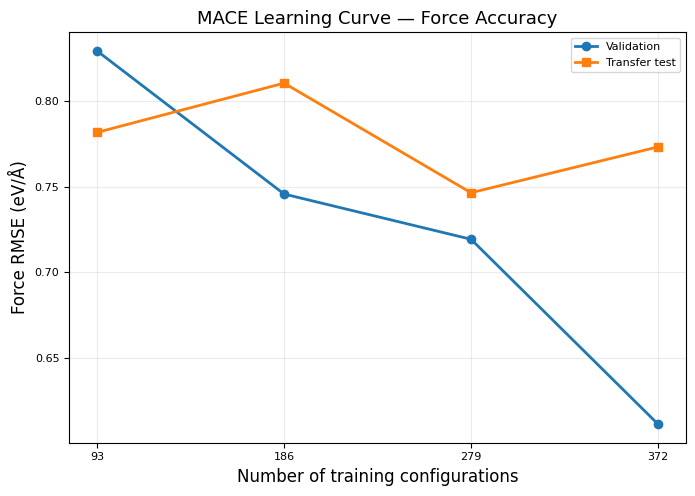


Saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/figures/mace_learning_curve_force_rmse.png


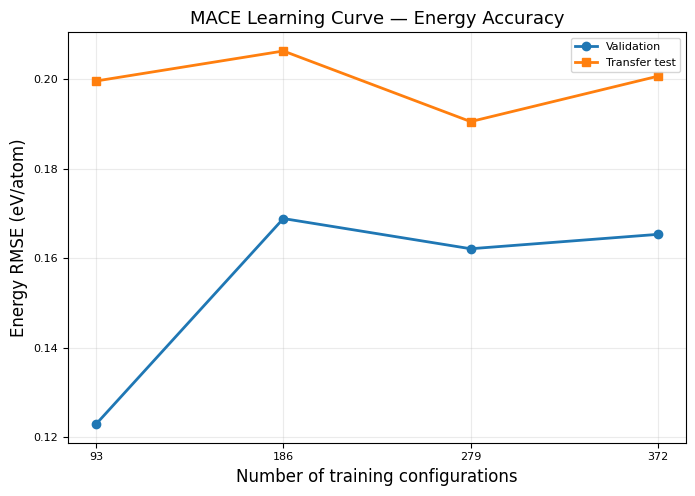


Saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/figures/mace_learning_curve_energy_rmse.png

FORCE RMSE SUMMARY


,Training size,Validation force RMSE (eV/A),Transfer force RMSE (eV/A)
0,93,0.8296,0.7819
1,186,0.7458,0.8107
2,279,0.7193,0.7465
3,372,0.6110,0.7734



LEARNING-CURVE PLOTS COMPLETE


In [9]:
# ============================================================
# CELL — LEARNING-CURVE PLOTS
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("LEARNING-CURVE PLOTS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves" /
    "metrics"
)

FIGURES_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves" /
    "figures"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_FILE = (
    METRICS_DIR /
    "mace_learning_curve_results.csv"
)

results = pd.read_csv(RESULTS_FILE)

# ------------------------------------------------------------
# Separate validation and transfer results
# ------------------------------------------------------------

validation = (
    results[
        results["dataset"] == "validation"
    ]
    .sort_values("training_size")
)

transfer = (
    results[
        results["dataset"] == "transfer"
    ]
    .sort_values("training_size")
)

training_sizes = validation["training_size"].values

# ------------------------------------------------------------
# Figure 1 — Force learning curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    validation["training_size"],
    validation["force_RMSE_eV_A"],
    marker="o",
    linewidth=2,
    label="Validation"
)

plt.plot(
    transfer["training_size"],
    transfer["force_RMSE_eV_A"],
    marker="s",
    linewidth=2,
    label="Transfer test"
)

plt.xlabel(
    "Number of training configurations",
    fontsize=12
)

plt.ylabel(
    "Force RMSE (eV/Å)",
    fontsize=12
)

plt.title(
    "MACE Learning Curve — Force Accuracy",
    fontsize=13
)

plt.xticks(training_sizes)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

FORCE_FIGURE = (
    FIGURES_DIR /
    "mace_learning_curve_force_rmse.png"
)

plt.savefig(
    FORCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(FORCE_FIGURE)

# ------------------------------------------------------------
# Figure 2 — Energy learning curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    validation["training_size"],
    validation["energy_RMSE_eV_atom"],
    marker="o",
    linewidth=2,
    label="Validation"
)

plt.plot(
    transfer["training_size"],
    transfer["energy_RMSE_eV_atom"],
    marker="s",
    linewidth=2,
    label="Transfer test"
)

plt.xlabel(
    "Number of training configurations",
    fontsize=12
)

plt.ylabel(
    "Energy RMSE (eV/atom)",
    fontsize=12
)

plt.title(
    "MACE Learning Curve — Energy Accuracy",
    fontsize=13
)

plt.xticks(training_sizes)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

ENERGY_FIGURE = (
    FIGURES_DIR /
    "mace_learning_curve_energy_rmse.png"
)

plt.savefig(
    ENERGY_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(ENERGY_FIGURE)

# ------------------------------------------------------------
# Compact summary
# ------------------------------------------------------------

print()
print("=" * 70)
print("FORCE RMSE SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "Training size": training_sizes,
    "Validation force RMSE (eV/A)": validation[
        "force_RMSE_eV_A"
    ].values,
    "Transfer force RMSE (eV/A)": transfer[
        "force_RMSE_eV_A"
    ].values,
})

display(
    summary.style.format({
        "Validation force RMSE (eV/A)": "{:.4f}",
        "Transfer force RMSE (eV/A)": "{:.4f}",
    })
)

print()
print("=" * 70)
print("LEARNING-CURVE PLOTS COMPLETE")
print("=" * 70)

In [10]:
# ============================================================
# CELL — MOLECULE-LEVEL TRANSFERABILITY ANALYSIS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from ase.io import read
from mace.calculators import MACECalculator
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 70)
print("MOLECULE-LEVEL TRANSFERABILITY ANALYSIS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

LEARNING_ROOT = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

MODEL_ROOT = LEARNING_ROOT / "models"

METRICS_DIR = LEARNING_ROOT / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load transfer set
# ------------------------------------------------------------

TRANSFER_FILE = (
    PROCESSED_DIR /
    "mace_test_transfer.extxyz"
)

transfer_atoms = read(
    str(TRANSFER_FILE),
    index=":"
)

print()
print(
    f"Transfer configurations loaded: "
    f"{len(transfer_atoms)}"
)

assert len(transfer_atoms) == 95

# ------------------------------------------------------------
# Identify transfer molecules
# ------------------------------------------------------------

transfer_df = pd.read_csv(
    PROCESSED_DIR / "molecule_split.csv"
)

transfer_molecules = transfer_df[
    transfer_df["split"] == "test_transfer"
].copy()

transfer_molecules = transfer_molecules.sort_values(
    "molecule_id"
)

print()
print("Transfer molecules:")
print(
    transfer_molecules[
        [
            "molecule_id",
            "molecule_name",
            "family"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Model paths
# ------------------------------------------------------------

model_paths = {
    93: (
        MODEL_ROOT /
        "size_93" /
        "energymol_learning_93_run-123.model"
    ),

    186: (
        MODEL_ROOT /
        "size_186" /
        "energymol_learning_186_run-123.model"
    ),

    279: (
        MODEL_ROOT /
        "size_279" /
        "energymol_learning_279_run-123.model"
    ),

    372: (
        PROJECT_DIR /
        "results" /
        "mace_baseline" /
        "checkpoints" /
        "energymol_mace_baseline_run-123.model"
    ),
}

# ------------------------------------------------------------
# Evaluate one molecule with one model
# ------------------------------------------------------------

def evaluate_molecule(
    model_path,
    molecule_id,
    dataset
):

    molecule_atoms = [
        atoms
        for atoms in dataset
        if str(
            atoms.info["molecule_id"]
        ) == str(molecule_id)
    ]

    if len(molecule_atoms) == 0:
        raise ValueError(
            f"No configurations found for {molecule_id}"
        )

    calculator = MACECalculator(
        model_paths=str(model_path),
        device="cpu",
        default_dtype="float32"
    )

    ref_energy = []
    pred_energy = []

    ref_forces = []
    pred_forces = []

    for atoms_original in molecule_atoms:

        reference_energy = float(
            atoms_original.info["energy_eV"]
        )

        reference_forces = np.asarray(
            atoms_original.calc.results["forces"],
            dtype=float
        )

        atoms = atoms_original.copy()
        atoms.calc = calculator

        predicted_energy = float(
            atoms.get_potential_energy()
        )

        predicted_forces = np.asarray(
            atoms.get_forces(),
            dtype=float
        )

        ref_energy.append(
            reference_energy / len(atoms)
        )

        pred_energy.append(
            predicted_energy / len(atoms)
        )

        ref_forces.append(
            reference_forces.reshape(-1)
        )

        pred_forces.append(
            predicted_forces.reshape(-1)
        )

    ref_energy = np.asarray(ref_energy)
    pred_energy = np.asarray(pred_energy)

    ref_forces = np.concatenate(ref_forces)
    pred_forces = np.concatenate(pred_forces)

    energy_error = pred_energy - ref_energy
    force_error = pred_forces - ref_forces

    return {
        "n_configurations": len(molecule_atoms),

        "energy_MAE_eV_atom": float(
            mean_absolute_error(
                ref_energy,
                pred_energy
            )
        ),

        "energy_RMSE_eV_atom": float(
            np.sqrt(
                mean_squared_error(
                    ref_energy,
                    pred_energy
                )
            )
        ),

        "mean_energy_error_eV_atom": float(
            np.mean(energy_error)
        ),

        "force_MAE_eV_A": float(
            mean_absolute_error(
                ref_forces,
                pred_forces
            )
        ),

        "force_RMSE_eV_A": float(
            np.sqrt(
                mean_squared_error(
                    ref_forces,
                    pred_forces
                )
            )
        ),

        "max_force_error_eV_A": float(
            np.max(
                np.abs(force_error)
            )
        ),
    }


# ------------------------------------------------------------
# Run analysis
# ------------------------------------------------------------

records = []

for training_size, model_path in model_paths.items():

    print()
    print("-" * 70)
    print(
        f"MODEL: {training_size} TRAINING CONFIGURATIONS"
    )
    print("-" * 70)

    for _, molecule in transfer_molecules.iterrows():

        molecule_id = molecule["molecule_id"]

        result = evaluate_molecule(
            model_path,
            molecule_id,
            transfer_atoms
        )

        records.append({
            "training_size": training_size,
            "molecule_id": molecule_id,
            "molecule_name": molecule["molecule_name"],
            "family": molecule["family"],
            **result
        })

        print(
            f"{molecule_id} | "
            f"{molecule['molecule_name']} | "
            f"Energy RMSE = "
            f"{result['energy_RMSE_eV_atom']:.4f} eV/atom | "
            f"Force RMSE = "
            f"{result['force_RMSE_eV_A']:.4f} eV/A"
        )

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

transfer_molecule_results = pd.DataFrame(records)

transfer_molecule_results = (
    transfer_molecule_results
    .sort_values(
        [
            "molecule_id",
            "training_size"
        ]
    )
    .reset_index(drop=True)
)

OUTPUT_FILE = (
    METRICS_DIR /
    "mace_learning_curve_transfer_by_molecule.csv"
)

transfer_molecule_results.to_csv(
    OUTPUT_FILE,
    index=False
)

# ------------------------------------------------------------
# Display compact table
# ------------------------------------------------------------

print()
print("=" * 70)
print("MOLECULE-LEVEL TRANSFER RESULTS")
print("=" * 70)

display(
    transfer_molecule_results[
        [
            "training_size",
            "molecule_id",
            "molecule_name",
            "family",
            "energy_RMSE_eV_atom",
            "force_RMSE_eV_A",
            "max_force_error_eV_A"
        ]
    ].style.format({
        "energy_RMSE_eV_atom": "{:.5f}",
        "force_RMSE_eV_A": "{:.5f}",
        "max_force_error_eV_A": "{:.5f}",
    })
)

print()
print("Saved:")
print(OUTPUT_FILE)

print()
print("=" * 70)
print("MOLECULE-LEVEL TRANSFER ANALYSIS COMPLETE")
print("=" * 70)

MOLECULE-LEVEL TRANSFERABILITY ANALYSIS

Transfer configurations loaded: 95

Transfer molecules:
molecule_id               molecule_name               family
        M01                     benzene aromatic_hydrocarbon
        M02                     toluene aromatic_hydrocarbon
        M14 4_dimethylaminobenzonitrile       donor_acceptor
        M16   2_4_nitrophenyl_thiophene       donor_acceptor

----------------------------------------------------------------------
MODEL: 93 TRAINING CONFIGURATIONS
----------------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


M01 | benzene | Energy RMSE = 0.0393 eV/atom | Force RMSE = 0.1129 eV/A


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


M02 | toluene | Energy RMSE = 0.1347 eV/atom | Force RMSE = 0.9388 eV/A


...

M14 | 4_dimethylaminobenzonitrile | Energy RMSE = 0.3711 eV/atom | Force RMSE = 1.1855 eV/A


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


M16 | 2_4_nitrophenyl_thiophene | Energy RMSE = 0.0024 eV/atom | Force RMSE = 0.1121 eV/A

MOLECULE-LEVEL TRANSFER RESULTS


,training_size,molecule_id,molecule_name,family,energy_RMSE_eV_atom,force_RMSE_eV_A,max_force_error_eV_A
0,93,M01,benzene,aromatic_hydrocarbon,0.03927,0.11291,0.49666
1,186,M01,benzene,aromatic_hydrocarbon,0.05804,0.09006,0.32248
2,279,M01,benzene,aromatic_hydrocarbon,0.05093,0.07381,0.29873
3,372,M01,benzene,aromatic_hydrocarbon,0.03410,0.06429,0.35509
4,93,M02,toluene,aromatic_hydrocarbon,0.13471,0.93883,5.40573
5,186,M02,toluene,aromatic_hydrocarbon,0.10441,0.94163,5.67703
6,279,M02,toluene,aromatic_hydrocarbon,0.10682,0.85035,5.01361
7,372,M02,toluene,aromatic_hydrocarbon,0.14351,0.86190,5.04685
8,93,M14,4_dimethylaminobenzonitrile,donor_acceptor,0.37147,1.15011,6.23474
9,186,M14,4_dimethylaminobenzonitrile,donor_acceptor,0.38991,1.21934,5.96532



Saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_transfer_by_molecule.csv

MOLECULE-LEVEL TRANSFER ANALYSIS COMPLETE


In [11]:
# ============================================================
# CELL 10 — FIND ORIGINAL MACE TRAINING CODE
# ============================================================

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

search_dirs = [
    PROJECT_DIR / "scripts",
    PROJECT_DIR / "results" / "mace_baseline",
    PROJECT_DIR / "results" / "mace_learning_curves",
    PROJECT_DIR / "data" / "processed",
]

keywords = [
    "mace_run_train",
    "MACECalculator",
    "hidden_irreps",
    "num_interactions",
    "max_ell",
    "r_max",
    "max_num_epochs",
    "energy_weight",
    "forces_weight",
    "mace_train.extxyz",
]

print("=" * 70)
print("SEARCHING FOR ORIGINAL MACE TRAINING CODE")
print("=" * 70)

matches = []

for directory in search_dirs:

    if not directory.exists():
        continue

    for path in directory.rglob("*"):

        if not path.is_file():
            continue

        # Only inspect text/code/config files
        if path.suffix.lower() not in {
            ".py", ".ipynb", ".sh", ".txt", ".json", ".yaml", ".yml"
        }:
            continue

        try:
            text_content = path.read_text(errors="ignore")
        except Exception:
            continue

        for keyword in keywords:

            if keyword.lower() in text_content.lower():

                matches.append((path, keyword))

                print(f"\nFOUND: {path}")
                print(f"KEYWORD: {keyword}")

                # Print relevant lines
                lines = text_content.splitlines()

                for i, line in enumerate(lines):

                    if keyword.lower() in line.lower():

                        start = max(0, i - 2)
                        end = min(len(lines), i + 4)

                        print("-" * 60)

                        for j in range(start, end):
                            print(f"{j+1:04d}: {lines[j]}")

                        break

print("\n" + "=" * 70)
print(f"TOTAL MATCHES: {len(matches)}")
print("=" * 70)

if not matches:
    print("No original training code was found in the searched directories.")

print("\nCELL 10 COMPLETE")

SEARCHING FOR ORIGINAL MACE TRAINING CODE

FOUND: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
KEYWORD: hidden_irreps
------------------------------------------------------------
0009:   "validation_size": 96,
0010:   "model": "MACE",
0011:   "hidden_irreps": "64x0e + 64x1o",
0012:   "num_interactions": 2,
0013:   "max_ell": 2,
0014:   "r_max": 5.0,

FOUND: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
KEYWORD: num_interactions
------------------------------------------------------------
0010:   "model": "MACE",
0011:   "hidden_irreps": "64x0e + 64x1o",
0012:   "num_interactions": 2,
0013:   "max_ell": 2,
0014:   "r_max": 5.0,
0015:   "max_num_epochs": 100,

FOUND: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
KEYWORD: max_ell
------------------------------------------------------------
0011:   "hidden_irreps": "64x0e + 64x1o",
0012:   "num_interact

In [13]:
# ============================================================
# CELL 11 — CONSOLIDATE LEARNING-CURVE RESULTS
# CORRECTED PATHS
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

# Training subsets were created here by Cell 5
LEARNING_DATA_DIR = (
    PROJECT_DIR / "results" / "learning_curve"
)

# MACE evaluation results are stored here
METRICS_DIR = (
    PROJECT_DIR
    / "results"
    / "mace_learning_curves"
    / "metrics"
)

sizes = [93, 186, 279, 372]

print("=" * 70)
print("MACE LEARNING-CURVE RESULT CONSOLIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check learning-curve training files
# ------------------------------------------------------------

print("\nChecking learning-curve training files...")

required_training_files = []

for size in sizes:
    required_training_files.append(
        LEARNING_DATA_DIR / f"mace_train_{size}.extxyz"
    )

for f in required_training_files:
    status = "OK" if f.exists() else "MISSING"
    print(f"{status:8s} {f}")

missing = [
    f for f in required_training_files
    if not f.exists()
]

assert not missing, f"Missing training files: {missing}"

# ------------------------------------------------------------
# 2. Check transfer results
# ------------------------------------------------------------

transfer_file = (
    METRICS_DIR
    / "mace_learning_curve_transfer_by_molecule.csv"
)

assert transfer_file.exists(), (
    f"Missing transfer results: {transfer_file}"
)

print(f"\nOK       {transfer_file}")

# ------------------------------------------------------------
# 3. Load transfer results
# ------------------------------------------------------------

transfer_df = pd.read_csv(transfer_file)

print("\n" + "-" * 70)
print("TRANSFER RESULT SUMMARY")
print("-" * 70)

print(f"Rows: {len(transfer_df)}")
print(
    f"Training sizes: "
    f"{sorted(transfer_df['training_size'].unique())}"
)
print(
    f"Molecules: "
    f"{sorted(transfer_df['molecule_id'].unique())}"
)

# ------------------------------------------------------------
# 4. Structural checks
# ------------------------------------------------------------

assert sorted(
    transfer_df["training_size"].unique().tolist()
) == sizes

assert transfer_df["molecule_id"].nunique() == 4

assert len(transfer_df) == 16

# ------------------------------------------------------------
# 5. Display molecule-level transfer results
# ------------------------------------------------------------

print("\nMolecule-level transfer results:")

display(
    transfer_df[
        [
            "training_size",
            "molecule_id",
            "molecule_name",
            "family",
            "energy_RMSE_eV_atom",
            "force_RMSE_eV_A",
            "max_force_error_eV_A",
        ]
    ]
    .sort_values(
        ["training_size", "molecule_id"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Calculate mean transfer metrics
# ------------------------------------------------------------

summary = (
    transfer_df
    .groupby("training_size")
    .agg(
        mean_energy_RMSE_eV_atom=(
            "energy_RMSE_eV_atom",
            "mean"
        ),
        mean_force_RMSE_eV_A=(
            "force_RMSE_eV_A",
            "mean"
        ),
        max_force_error_eV_A=(
            "max_force_error_eV_A",
            "max"
        ),
    )
    .reset_index()
)

print("\n" + "-" * 70)
print("MEAN TRANSFER PERFORMANCE")
print("-" * 70)

display(summary)

# ------------------------------------------------------------
# 7. Save consolidated summary
# ------------------------------------------------------------

output_file = (
    METRICS_DIR
    / "mace_learning_curve_transfer_summary.csv"
)

summary.to_csv(output_file, index=False)

print("\nSaved:")
print(output_file)

print("\n" + "=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

MACE LEARNING-CURVE RESULT CONSOLIDATION

Checking learning-curve training files...
OK       /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_93.extxyz
OK       /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_186.extxyz
OK       /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_279.extxyz
OK       /content/drive/MyDrive/MLIP project/results/learning_curve/mace_train_372.extxyz

OK       /content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_transfer_by_molecule.csv

----------------------------------------------------------------------
TRANSFER RESULT SUMMARY
----------------------------------------------------------------------
Rows: 16
Training sizes: [np.int64(93), np.int64(186), np.int64(279), np.int64(372)]
Molecules: ['M01', 'M02', 'M14', 'M16']

Molecule-level transfer results:


,training_size,molecule_id,molecule_name,family,energy_RMSE_eV_atom,force_RMSE_eV_A,max_force_error_eV_A
0,93,M01,benzene,aromatic_hydrocarbon,0.039275,0.112910,0.496659
1,93,M02,toluene,aromatic_hydrocarbon,0.134714,0.938826,5.405732
2,93,M14,4_dimethylaminobenzonitrile,donor_acceptor,0.371469,1.150114,6.234744
3,93,M16,2_4_nitrophenyl_thiophene,donor_acceptor,0.009628,0.186657,1.007635
4,186,M01,benzene,aromatic_hydrocarbon,0.058041,0.090063,0.322484
5,186,M02,toluene,aromatic_hydrocarbon,0.104410,0.941628,5.677032
6,186,M14,4_dimethylaminobenzonitrile,donor_acceptor,0.389910,1.219341,5.965320
7,186,M16,2_4_nitrophenyl_thiophene,donor_acceptor,0.048195,0.139328,0.775267
8,279,M01,benzene,aromatic_hydrocarbon,0.050933,0.073808,0.298727
9,279,M02,toluene,aromatic_hydrocarbon,0.106823,0.850351,5.013610



----------------------------------------------------------------------
MEAN TRANSFER PERFORMANCE
----------------------------------------------------------------------


,training_size,mean_energy_RMSE_eV_atom,mean_force_RMSE_eV_A,max_force_error_eV_A
0,93,0.138772,0.597127,6.234744
1,186,0.150139,0.597590,5.965320
2,279,0.133148,0.546663,6.006698
3,372,0.137765,0.555946,6.306652



Saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_transfer_summary.csv

CELL 11 COMPLETE


In [14]:
# ============================================================
# CELL 12 — BUILD MAIN LEARNING-CURVE METRICS TABLE
# ============================================================

from pathlib import Path
import pandas as pd
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LC_DIR = (
    PROJECT_DIR
    / "results"
    / "mace_learning_curves"
)

METRICS_DIR = LC_DIR / "metrics"

sizes = [93, 186, 279, 372]

print("=" * 70)
print("SEARCHING FOR LEARNING-CURVE METRICS")
print("=" * 70)

# ------------------------------------------------------------
# Find JSON / CSV metric files
# ------------------------------------------------------------

metric_files = []

for path in LC_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in {".json", ".csv"}:
        metric_files.append(path)

for path in sorted(metric_files):
    print(path)

# ------------------------------------------------------------
# Look for files containing size-specific metrics
# ------------------------------------------------------------

candidate_files = []

for path in metric_files:

    name = path.name.lower()

    if (
        "learning" in name
        or "curve" in name
        or "metric" in name
        or "result" in name
        or "prediction" in name
    ):
        candidate_files.append(path)

print("\n" + "=" * 70)
print("CANDIDATE METRIC FILES")
print("=" * 70)

for path in candidate_files:
    print(path)

print("\n" + "=" * 70)
print("CELL 12 COMPLETE")
print("=" * 70)

SEARCHING FOR LEARNING-CURVE METRICS
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/learning_curve_validation_metrics.csv
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_results.csv
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_transfer_by_molecule.csv
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_transfer_summary.csv

CANDIDATE METRIC FILES
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/learning_curve_validation_metrics.csv
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curve_results.csv
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/mace_learning_curv

In [15]:
# ============================================================
# CELL 13 — INSPECT LEARNING-CURVE METRICS
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR
    / "results"
    / "mace_learning_curves"
    / "metrics"
)

files = [
    METRICS_DIR / "learning_curve_validation_metrics.csv",
    METRICS_DIR / "mace_learning_curve_results.csv",
]

print("=" * 70)
print("INSPECTING LEARNING-CURVE METRIC FILES")
print("=" * 70)

for file in files:

    print("\n" + "=" * 70)
    print(f"FILE: {file.name}")
    print("=" * 70)

    assert file.exists(), f"Missing file: {file}"

    df = pd.read_csv(file)

    print(f"\nShape: {df.shape}")

    print("\nColumns:")
    for col in df.columns:
        print(f"  - {col}")

    print("\nData:")
    display(df)

print("\n" + "=" * 70)
print("CELL 13 COMPLETE")
print("=" * 70)

INSPECTING LEARNING-CURVE METRIC FILES

FILE: learning_curve_validation_metrics.csv

Shape: (4, 7)

Columns:
  - training_size
  - energy_MAE_eV_atom
  - energy_RMSE_eV_atom
  - energy_R2
  - force_MAE_eV_A
  - force_RMSE_eV_A
  - force_R2

Data:


,training_size,energy_MAE_eV_atom,energy_RMSE_eV_atom,energy_R2,force_MAE_eV_A,force_RMSE_eV_A,force_R2
0,93,0.110472,0.122933,1.0,0.446726,0.829551,0.774122
1,186,0.154120,0.168864,1.0,0.397497,0.745761,0.817447
2,279,0.144788,0.162115,1.0,0.375451,0.719269,0.830187
3,372,0.149793,0.165332,1.0,0.335084,0.611027,0.877451



FILE: mace_learning_curve_results.csv

Shape: (8, 8)

Columns:
  - training_size
  - dataset
  - energy_MAE_eV_atom
  - energy_RMSE_eV_atom
  - energy_R2
  - force_MAE_eV_A
  - force_RMSE_eV_A
  - force_R2

Data:


,training_size,dataset,energy_MAE_eV_atom,energy_RMSE_eV_atom,energy_R2,force_MAE_eV_A,force_RMSE_eV_A,force_R2
0,93,transfer,0.139427,0.199605,1.0,0.385100,0.781886,0.732561
1,186,transfer,0.150740,0.206310,1.0,0.377515,0.810727,0.712468
2,279,transfer,0.133700,0.190529,1.0,0.337130,0.746524,0.756205
3,372,transfer,0.138536,0.200676,1.0,0.340582,0.773367,0.738357
4,93,validation,0.110472,0.122933,1.0,0.446726,0.829551,0.774122
5,186,validation,0.154120,0.168864,1.0,0.397497,0.745761,0.817447
6,279,validation,0.144788,0.162115,1.0,0.375451,0.719269,0.830187
7,372,validation,0.149793,0.165332,1.0,0.335084,0.611027,0.877451



CELL 13 COMPLETE


LOADED EXISTING LEARNING-CURVE RESULTS

Validation columns:
['training_size', 'energy_MAE_eV_atom', 'energy_RMSE_eV_atom', 'energy_R2', 'force_MAE_eV_A', 'force_RMSE_eV_A', 'force_R2']

Transfer-by-molecule columns:
['training_size', 'molecule_id', 'molecule_name', 'family', 'n_configurations', 'energy_MAE_eV_atom', 'energy_RMSE_eV_atom', 'mean_energy_error_eV_atom', 'force_MAE_eV_A', 'force_RMSE_eV_A', 'max_force_error_eV_A']


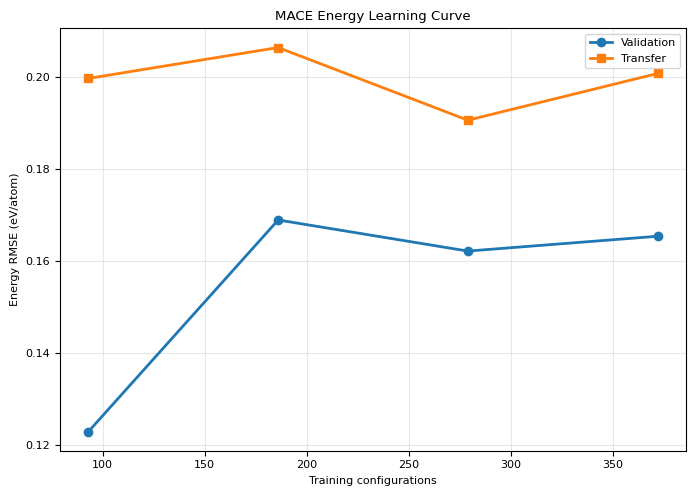

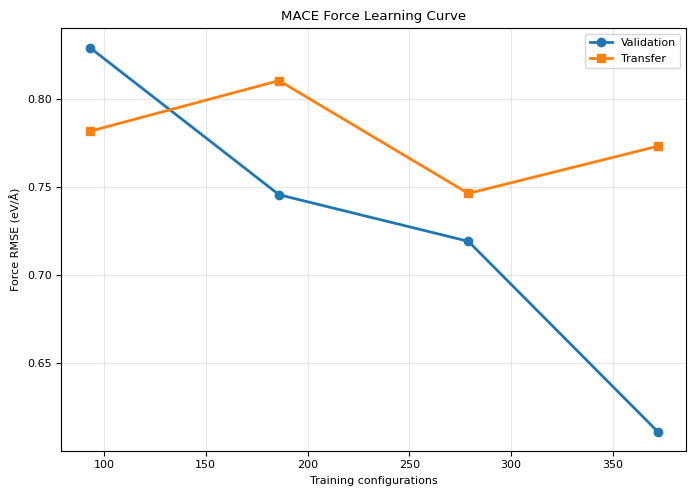

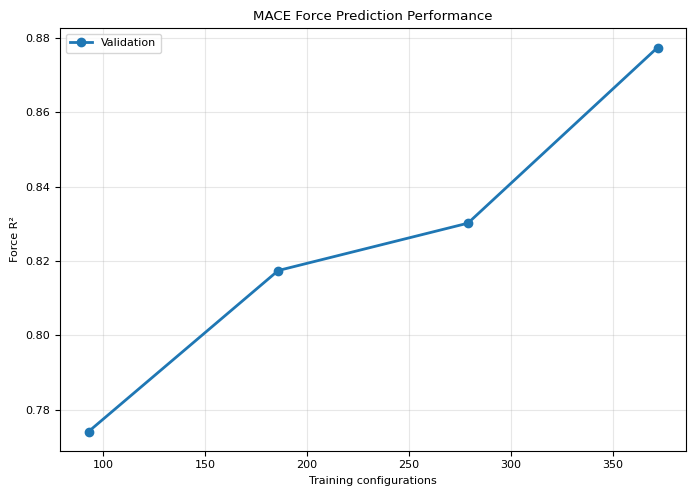

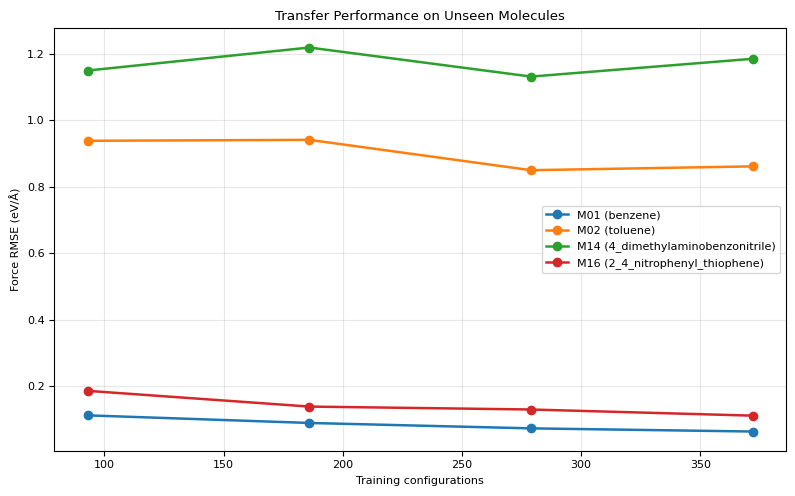


LEARNING-CURVE ANALYSIS COMPLETE

VALIDATION RESULTS
---------------------------------------------------------------------------
 training_size  energy_RMSE_eV_atom  force_RMSE_eV_A  force_R2
            93             0.122933         0.829551  0.774122
           186             0.168864         0.745761  0.817447
           279             0.162115         0.719269  0.830187
           372             0.165332         0.611027  0.877451

BEST VALIDATION MODELS
---------------------------------------------------------------------------
         criterion  training_size    value    unit
Lowest energy RMSE             93 0.122933 eV/atom
 Lowest force RMSE            372 0.611027    eV/A
  Highest force R2            372 0.877451      R2

DATA-EFFICIENCY SUMMARY
---------------------------------------------------------------------------
 initial_training_size  final_training_size  energy_RMSE_initial_eV_atom  energy_RMSE_final_eV_atom  energy_RMSE_improvement_percent  force_RMSE_initi

In [17]:
# ================================================================
# CELL 14: COMPLETE LEARNING-CURVE ANALYSIS
# Robust version: automatically handles available transfer columns
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# ------------------------------------------------
# 1. PATHS
# ------------------------------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = PROJECT_DIR / "results" / "mace_learning_curves" / "metrics"
FIG_DIR = PROJECT_DIR / "results" / "figures"
FINAL_DIR = PROJECT_DIR / "results" / "final_project"

FIG_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 2. LOAD EXISTING RESULTS
# ------------------------------------------------
validation_file = METRICS_DIR / "learning_curve_validation_metrics.csv"
results_file = METRICS_DIR / "mace_learning_curve_results.csv"
transfer_file = METRICS_DIR / "mace_learning_curve_transfer_by_molecule.csv"

validation = pd.read_csv(validation_file)
all_results = pd.read_csv(results_file)
transfer = pd.read_csv(transfer_file)

validation = validation.sort_values("training_size").reset_index(drop=True)

all_results = all_results.sort_values(
    ["dataset", "training_size"]
).reset_index(drop=True)

transfer = transfer.sort_values(
    ["molecule_id", "training_size"]
).reset_index(drop=True)

print("=" * 75)
print("LOADED EXISTING LEARNING-CURVE RESULTS")
print("=" * 75)

print("\nValidation columns:")
print(validation.columns.tolist())

print("\nTransfer-by-molecule columns:")
print(transfer.columns.tolist())

# ------------------------------------------------
# 3. CONSOLIDATED LEARNING-CURVE TABLE
# ------------------------------------------------
val = validation.copy()
val["dataset"] = "validation"

trans = all_results[
    all_results["dataset"].str.lower() == "transfer"
].copy()

learning_curve = pd.concat(
    [val, trans],
    ignore_index=True
)

learning_curve = learning_curve[
    [
        "training_size",
        "dataset",
        "energy_MAE_eV_atom",
        "energy_RMSE_eV_atom",
        "energy_R2",
        "force_MAE_eV_A",
        "force_RMSE_eV_A",
        "force_R2"
    ]
].sort_values(
    ["training_size", "dataset"]
).reset_index(drop=True)

learning_curve.to_csv(
    FINAL_DIR / "final_learning_curve_results.csv",
    index=False
)

# ------------------------------------------------
# 4. VALIDATION IMPROVEMENT ANALYSIS
# ------------------------------------------------
comparison = validation.copy()

comparison["energy_RMSE_change_vs_93_%"] = (
    (
        comparison["energy_RMSE_eV_atom"]
        / comparison.loc[0, "energy_RMSE_eV_atom"]
    ) - 1
) * 100

comparison["force_RMSE_change_vs_93_%"] = (
    (
        comparison["force_RMSE_eV_A"]
        / comparison.loc[0, "force_RMSE_eV_A"]
    ) - 1
) * 100

comparison["force_RMSE_improvement_vs_93_%"] = (
    1 -
    comparison["force_RMSE_eV_A"]
    / comparison.loc[0, "force_RMSE_eV_A"]
) * 100

comparison.to_csv(
    FINAL_DIR / "learning_curve_improvement_analysis.csv",
    index=False
)

# ------------------------------------------------
# 5. DATA-EFFICIENCY SUMMARY
# ------------------------------------------------
first = validation.iloc[0]
last = validation.iloc[-1]

energy_rmse_improvement = (
    (first["energy_RMSE_eV_atom"] -
     last["energy_RMSE_eV_atom"])
    / first["energy_RMSE_eV_atom"]
) * 100

force_rmse_improvement = (
    (first["force_RMSE_eV_A"] -
     last["force_RMSE_eV_A"])
    / first["force_RMSE_eV_A"]
) * 100

force_r2_improvement = (
    last["force_R2"] -
    first["force_R2"]
)

summary = pd.DataFrame([{
    "initial_training_size": int(first["training_size"]),
    "final_training_size": int(last["training_size"]),
    "energy_RMSE_initial_eV_atom": first["energy_RMSE_eV_atom"],
    "energy_RMSE_final_eV_atom": last["energy_RMSE_eV_atom"],
    "energy_RMSE_improvement_percent": energy_rmse_improvement,
    "force_RMSE_initial_eV_A": first["force_RMSE_eV_A"],
    "force_RMSE_final_eV_A": last["force_RMSE_eV_A"],
    "force_RMSE_improvement_percent": force_rmse_improvement,
    "force_R2_initial": first["force_R2"],
    "force_R2_final": last["force_R2"],
    "force_R2_absolute_improvement": force_r2_improvement
}])

summary.to_csv(
    FINAL_DIR / "data_efficiency_summary.csv",
    index=False
)

# ------------------------------------------------
# 6. BEST VALIDATION MODELS
# ------------------------------------------------
best_energy = validation.loc[
    validation["energy_RMSE_eV_atom"].idxmin()
]

best_force = validation.loc[
    validation["force_RMSE_eV_A"].idxmin()
]

best_force_r2 = validation.loc[
    validation["force_R2"].idxmax()
]

best_models = pd.DataFrame([
    {
        "criterion": "Lowest energy RMSE",
        "training_size": int(best_energy["training_size"]),
        "value": best_energy["energy_RMSE_eV_atom"],
        "unit": "eV/atom"
    },
    {
        "criterion": "Lowest force RMSE",
        "training_size": int(best_force["training_size"]),
        "value": best_force["force_RMSE_eV_A"],
        "unit": "eV/A"
    },
    {
        "criterion": "Highest force R2",
        "training_size": int(best_force_r2["training_size"]),
        "value": best_force_r2["force_R2"],
        "unit": "R2"
    }
])

best_models.to_csv(
    FINAL_DIR / "best_validation_models.csv",
    index=False
)

# ------------------------------------------------
# 7. TRANSFER SUMMARY
#
# Use only columns actually present in the
# molecule-level transfer file.
# ------------------------------------------------
transfer_agg = {
    "energy_RMSE_eV_atom": ["mean"],
    "force_RMSE_eV_A": ["mean"],
    "energy_MAE_eV_atom": ["mean"],
    "force_MAE_eV_A": ["mean"],
    "max_force_error_eV_A": ["max"]
}

# Remove metrics that are not present
transfer_agg = {
    col: funcs
    for col, funcs in transfer_agg.items()
    if col in transfer.columns
}

transfer_summary = (
    transfer
    .groupby("training_size")
    .agg(transfer_agg)
)

# Flatten MultiIndex column names
transfer_summary.columns = [
    f"{col}_{func}"
    for col, func in transfer_summary.columns
]

transfer_summary = transfer_summary.reset_index()

transfer_summary.to_csv(
    FINAL_DIR / "final_transfer_summary.csv",
    index=False
)

# ------------------------------------------------
# 8. FIGURE 1: ENERGY LEARNING CURVE
# ------------------------------------------------
plt.figure(figsize=(7, 5))

transfer_energy = (
    trans.groupby("training_size")["energy_RMSE_eV_atom"]
    .mean()
)

plt.plot(
    validation["training_size"],
    validation["energy_RMSE_eV_atom"],
    marker="o",
    linewidth=2,
    label="Validation"
)

plt.plot(
    transfer_energy.index,
    transfer_energy.values,
    marker="s",
    linewidth=2,
    label="Transfer"
)

plt.xlabel("Training configurations")
plt.ylabel("Energy RMSE (eV/atom)")
plt.title("MACE Energy Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "mace_energy_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------
# 9. FIGURE 2: FORCE LEARNING CURVE
# ------------------------------------------------
plt.figure(figsize=(7, 5))

transfer_force = (
    trans.groupby("training_size")["force_RMSE_eV_A"]
    .mean()
)

plt.plot(
    validation["training_size"],
    validation["force_RMSE_eV_A"],
    marker="o",
    linewidth=2,
    label="Validation"
)

plt.plot(
    transfer_force.index,
    transfer_force.values,
    marker="s",
    linewidth=2,
    label="Transfer"
)

plt.xlabel("Training configurations")
plt.ylabel("Force RMSE (eV/Å)")
plt.title("MACE Force Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "mace_force_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------
# 10. FIGURE 3: FORCE R2
# ------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(
    validation["training_size"],
    validation["force_R2"],
    marker="o",
    linewidth=2,
    label="Validation"
)

plt.xlabel("Training configurations")
plt.ylabel("Force R²")
plt.title("MACE Force Prediction Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "mace_force_r2_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------
# 11. FIGURE 4: TRANSFER PERFORMANCE BY MOLECULE
# ------------------------------------------------
plt.figure(figsize=(8, 5))

for molecule_id, group in transfer.groupby("molecule_id"):
    label = molecule_id

    if "molecule_name" in group.columns:
        name = group["molecule_name"].iloc[0]
        label = f"{molecule_id} ({name})"

    plt.plot(
        group["training_size"],
        group["force_RMSE_eV_A"],
        marker="o",
        linewidth=1.8,
        label=label
    )

plt.xlabel("Training configurations")
plt.ylabel("Force RMSE (eV/Å)")
plt.title("Transfer Performance on Unseen Molecules")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "mace_transfer_force_by_molecule.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------
# 12. PRINT RESULTS
# ------------------------------------------------
print("\n" + "=" * 75)
print("LEARNING-CURVE ANALYSIS COMPLETE")
print("=" * 75)

print("\nVALIDATION RESULTS")
print("-" * 75)

print(
    validation[
        [
            "training_size",
            "energy_RMSE_eV_atom",
            "force_RMSE_eV_A",
            "force_R2"
        ]
    ].to_string(index=False)
)

print("\nBEST VALIDATION MODELS")
print("-" * 75)
print(best_models.to_string(index=False))

print("\nDATA-EFFICIENCY SUMMARY")
print("-" * 75)
print(summary.to_string(index=False))

print("\nTRANSFER SUMMARY")
print("-" * 75)
print(transfer_summary.to_string(index=False))

print("\nKEY FINDINGS")
print("-" * 75)

print(
    f"Energy RMSE: {first['energy_RMSE_eV_atom']:.4f} → "
    f"{last['energy_RMSE_eV_atom']:.4f} eV/atom "
    f"({energy_rmse_improvement:.1f}% change)."
)

print(
    f"Force RMSE: {first['force_RMSE_eV_A']:.4f} → "
    f"{last['force_RMSE_eV_A']:.4f} eV/A "
    f"({force_rmse_improvement:.1f}% improvement)."
)

print(
    f"Force R²: {first['force_R2']:.4f} → "
    f"{last['force_R2']:.4f}."
)

print(
    "\nTransfer performance varies between unseen molecules. "
    "This indicates that increasing the number of configurations "
    "from the existing training molecules does not guarantee "
    "uniform improvement on chemically distinct molecules."
)

# ------------------------------------------------
# 13. SAVE MACHINE-READABLE SUMMARY
# ------------------------------------------------
json_summary = {
    "training_sizes": validation["training_size"].astype(int).tolist(),

    "validation": validation.to_dict(orient="records"),

    "best_validation": best_models.to_dict(orient="records"),

    "data_efficiency": summary.to_dict(orient="records"),

    "transfer_summary": transfer_summary.to_dict(orient="records"),

    "files_created": [
        "final_learning_curve_results.csv",
        "learning_curve_improvement_analysis.csv",
        "data_efficiency_summary.csv",
        "best_validation_models.csv",
        "final_transfer_summary.csv",
        "mace_energy_learning_curve.png",
        "mace_force_learning_curve.png",
        "mace_force_r2_learning_curve.png",
        "mace_transfer_force_by_molecule.png"
    ]
}

with open(
    FINAL_DIR / "learning_curve_analysis_summary.json",
    "w"
) as f:
    json.dump(json_summary, f, indent=2)

# ------------------------------------------------
# 14. FINAL FILE CHECK
# ------------------------------------------------
print("\n" + "=" * 75)
print("FILES CREATED")
print("=" * 75)

for file in sorted(FINAL_DIR.iterdir()):
    print(" ", file.name)

print("\nFigures:")
for file in sorted(FIG_DIR.glob("mace_*.png")):
    print(" ", file.name)

print("\n" + "=" * 75)
print("CELL 14 COMPLETE")
print("=" * 75)

In [20]:
# ================================================================
# CELL 15: FINAL ENERGYMOL-MLIP PROJECT QC
# Checks dataset, splits, labels, baseline, learning curves,
# transferability, and final project completeness.
# NO RETRAINING.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

DATA_DIR = PROJECT_DIR / "data" / "processed"
METRICS_DIR = PROJECT_DIR / "results" / "metrics"
LC_DIR = PROJECT_DIR / "results" / "mace_learning_curves" / "metrics"
FINAL_DIR = PROJECT_DIR / "results" / "final_project"
FIG_DIR = PROJECT_DIR / "results" / "figures"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("ENERGYMOL-MLIP FINAL PROJECT QUALITY CONTROL")
print("=" * 80)

# ================================================================
# 1. EXPECTED FILES
# ================================================================

expected_files = {
    "DFT dataset":
        DATA_DIR / "dft_dataset.extxyz",

    "MACE dataset":
        DATA_DIR / "dft_dataset_mace.extxyz",

    "DFT results":
        DATA_DIR / "dft_results_raw.csv",

    "Dataset manifest":
        DATA_DIR / "dft_dataset_manifest.csv",

    "Molecule split":
        DATA_DIR / "molecule_split.csv",

    "MACE train":
        DATA_DIR / "mace_train.extxyz",

    "MACE validation":
        DATA_DIR / "mace_validation.extxyz",

    "MACE transfer":
        DATA_DIR / "mace_test_transfer.extxyz",

    "Baseline final table":
        METRICS_DIR / "mace_final_results_table.csv",

    "Baseline predictions":
        METRICS_DIR / "mace_baseline_predictions.csv",

    "Baseline consolidated metrics":
        METRICS_DIR / "mace_baseline_consolidated_metrics.csv",

    "Transfer summary":
        METRICS_DIR / "mace_transferability_summary.json",

    "Learning curve validation":
        LC_DIR / "learning_curve_validation_metrics.csv",

    "Learning curve results":
        LC_DIR / "mace_learning_curve_results.csv",

    "Transfer by molecule":
        LC_DIR / "mace_learning_curve_transfer_by_molecule.csv",

    "Transfer summary":
        LC_DIR / "mace_learning_curve_transfer_summary.csv",

    "Learning curve config":
        PROJECT_DIR / "results" / "mace_learning_curves" /
        "learning_curve_config.json"
}

file_status = []

for name, path in expected_files.items():

    exists = path.exists()

    file_status.append({
        "item": name,
        "exists": exists,
        "path": str(path)
    })

    status = "OK" if exists else "MISSING"

    print(f"[{status:7}] {name}")

file_status_df = pd.DataFrame(file_status)

file_status_df.to_csv(
    FINAL_DIR / "final_project_file_check.csv",
    index=False
)

# ================================================================
# 2. DATASET QC
# ================================================================

print("\n" + "=" * 80)
print("DATASET QC")
print("=" * 80)

dataset_file = DATA_DIR / "dft_dataset_manifest.csv"

dataset_ok = False

if dataset_file.exists():

    manifest = pd.read_csv(dataset_file)

    print(f"\nManifest shape: {manifest.shape}")

    print("\nManifest columns:")
    print(manifest.columns.tolist())

    # Find likely molecule/configuration columns
    molecule_candidates = [
        "molecule_id",
        "molecule",
        "molecule_name"
    ]

    config_candidates = [
        "configuration_id",
        "config_id",
        "configuration"
    ]

    molecule_col = next(
        (c for c in molecule_candidates if c in manifest.columns),
        None
    )

    config_col = next(
        (c for c in config_candidates if c in manifest.columns),
        None
    )

    if molecule_col:
        n_molecules = manifest[molecule_col].nunique()
    else:
        n_molecules = None

    n_configs = len(manifest)

    print(f"\nConfigurations in manifest: {n_configs}")

    if n_molecules is not None:
        print(f"Unique molecules: {n_molecules}")

    dataset_ok = (
        n_configs == 563
        and (n_molecules == 24 if n_molecules is not None else True)
    )

    print(
        "\nDataset size check:",
        "PASS" if dataset_ok else "CHECK"
    )

else:
    manifest = None
    print("Manifest missing.")

# ================================================================
# 3. MOLECULE SPLIT QC
# ================================================================

print("\n" + "=" * 80)
print("MOLECULE SPLIT QC")
print("=" * 80)

split_file = DATA_DIR / "molecule_split.csv"

split_ok = False

if split_file.exists():

    split = pd.read_csv(split_file)

    print("\nSplit columns:")
    print(split.columns.tolist())

    print("\nMolecule split:")
    print(split.to_string(index=False))

    split_col = None

    for c in ["split", "dataset", "set"]:
        if c in split.columns:
            split_col = c
            break

    if split_col:

        print("\nSplit counts:")
        print(split[split_col].value_counts())

        train_names = [
            "train",
            "training"
        ]

        validation_names = [
            "validation",
            "val"
        ]

        transfer_names = [
            "transfer",
            "test",
            "test_transfer"
        ]

        split_values = set(
            str(x).lower()
            for x in split[split_col].unique()
        )

        split_ok = (
            any(x in split_values for x in train_names)
            and any(x in split_values for x in validation_names)
            and any(x in split_values for x in transfer_names)
        )

    else:
        print("\nNo split column detected.")

else:
    split = None
    print("Molecule split file missing.")

print(
    "\nMolecule split check:",
    "PASS" if split_ok else "CHECK"
)

# ================================================================
# 4. CONFIGURATION COUNTS
# ================================================================

print("\n" + "=" * 80)
print("CONFIGURATION SPLIT QC")
print("=" * 80)

split_files = {
    "Training": DATA_DIR / "mace_train.extxyz",
    "Validation": DATA_DIR / "mace_validation.extxyz",
    "Transfer": DATA_DIR / "mace_test_transfer.extxyz"
}

for name, path in split_files.items():

    if path.exists():

        try:
            from ase.io import read

            atoms_list = read(path, index=":")

            print(
                f"{name:12}: "
                f"{len(atoms_list)} configurations"
            )

        except Exception as e:

            print(
                f"{name:12}: could not read with ASE "
                f"({type(e).__name__})"
            )

    else:

        print(f"{name:12}: MISSING")

# ================================================================
# 5. LEARNING CURVE QC
# ================================================================

print("\n" + "=" * 80)
print("LEARNING-CURVE QC")
print("=" * 80)

lc_file = LC_DIR / "learning_curve_validation_metrics.csv"

lc_ok = False

if lc_file.exists():

    lc = pd.read_csv(lc_file)

    expected_sizes = [93, 186, 279, 372]

    actual_sizes = lc["training_size"].astype(int).tolist()

    print("Expected training sizes:", expected_sizes)
    print("Actual training sizes:  ", actual_sizes)

    size_ok = actual_sizes == expected_sizes

    required_lc_columns = [
        "training_size",
        "energy_RMSE_eV_atom",
        "force_RMSE_eV_A",
        "force_R2"
    ]

    columns_ok = all(
        c in lc.columns
        for c in required_lc_columns
    )

    no_nan = not lc[required_lc_columns].isna().any().any()

    lc_ok = size_ok and columns_ok and no_nan

    print("\nTraining-size check:",
          "PASS" if size_ok else "CHECK")

    print("Required-column check:",
          "PASS" if columns_ok else "CHECK")

    print("NaN check:",
          "PASS" if no_nan else "CHECK")

    print("\nLearning curve:")
    print(
        lc[
            [
                "training_size",
                "energy_RMSE_eV_atom",
                "force_RMSE_eV_A",
                "force_R2"
            ]
        ].to_string(index=False)
    )

else:

    print("Learning curve file missing.")

# ================================================================
# 6. TRANSFER QC
# ================================================================

print("\n" + "=" * 80)
print("TRANSFERABILITY QC")
print("=" * 80)

transfer_file = LC_DIR / "mace_learning_curve_transfer_by_molecule.csv"

transfer_ok = False

if transfer_file.exists():

    transfer = pd.read_csv(transfer_file)

    print(
        f"Transfer rows: {len(transfer)}"
    )

    print(
        f"Unique transfer molecules: "
        f"{transfer['molecule_id'].nunique()}"
    )

    print(
        f"Training sizes represented: "
        f"{sorted(transfer['training_size'].unique())}"
    )

    print("\nTransfer molecules:")

    if "molecule_name" in transfer.columns:

        molecule_table = (
            transfer[
                [
                    "molecule_id",
                    "molecule_name",
                    "family"
                ]
            ]
            .drop_duplicates()
            .sort_values("molecule_id")
        )

        print(
            molecule_table.to_string(index=False)
        )

    required_transfer = [
        "training_size",
        "molecule_id",
        "energy_RMSE_eV_atom",
        "force_RMSE_eV_A",
        "max_force_error_eV_A"
    ]

    columns_ok = all(
        c in transfer.columns
        for c in required_transfer
    )

    no_nan = not transfer[required_transfer].isna().any().any()

    transfer_ok = (
        transfer["molecule_id"].nunique() == 4
        and sorted(
            transfer["training_size"].unique()
        ) == [93, 186, 279, 372]
        and columns_ok
        and no_nan
    )

    print(
        "\nTransfer check:",
        "PASS" if transfer_ok else "CHECK"
    )

else:

    transfer = None
    print("Transfer file missing.")

# ================================================================
# 7. BASELINE QC
# ================================================================

print("\n" + "=" * 80)
print("BASELINE MODEL QC")
print("=" * 80)

baseline_file = METRICS_DIR / "mace_final_results_table.csv"

baseline_ok = False

if baseline_file.exists():

    baseline = pd.read_csv(baseline_file)

    print("Baseline table shape:", baseline.shape)

    print("\nBaseline columns:")
    print(baseline.columns.tolist())

    print("\nBaseline table:")
    print(baseline.to_string(index=False))

    baseline_ok = len(baseline) > 0

else:

    baseline = None
    print("Baseline results table missing.")

print(
    "\nBaseline check:",
    "PASS" if baseline_ok else "CHECK"
)

# ================================================================
# 8. FINAL FIGURE QC
# ================================================================

print("\n" + "=" * 80)
print("FIGURE QC")
print("=" * 80)

expected_figures = [
    "mace_energy_learning_curve.png",
    "mace_force_learning_curve.png",
    "mace_force_r2_learning_curve.png",
    "mace_transfer_force_by_molecule.png"
]

figure_status = []

for name in expected_figures:

    path = FIG_DIR / name
    exists = path.exists()

    figure_status.append({
        "figure": name,
        "exists": exists
    })

    print(
        f"[{'OK' if exists else 'MISSING':7}] {name}"
    )

figure_df = pd.DataFrame(figure_status)

figure_df.to_csv(
    FINAL_DIR / "final_project_figure_check.csv",
    index=False
)

figures_ok = figure_df["exists"].all()

# ================================================================
# 9. LEARNING-CURVE INTERPRETATION
# ================================================================

print("\n" + "=" * 80)
print("SCIENTIFIC INTERPRETATION CHECK")
print("=" * 80)

if lc_file.exists():

    first = lc.iloc[0]
    last = lc.iloc[-1]

    energy_change = (
        (last["energy_RMSE_eV_atom"] /
         first["energy_RMSE_eV_atom"]) - 1
    ) * 100

    force_improvement = (
        (first["force_RMSE_eV_A"] -
         last["force_RMSE_eV_A"])
        / first["force_RMSE_eV_A"]
    ) * 100

    force_r2_change = (
        last["force_R2"] -
        first["force_R2"]
    )

    print(
        f"Energy RMSE: "
        f"{first['energy_RMSE_eV_atom']:.4f} → "
        f"{last['energy_RMSE_eV_atom']:.4f} eV/atom"
    )

    print(
        f"Energy RMSE relative change: "
        f"{energy_change:+.1f}%"
    )

    print(
        f"Force RMSE: "
        f"{first['force_RMSE_eV_A']:.4f} → "
        f"{last['force_RMSE_eV_A']:.4f} eV/A"
    )

    print(
        f"Force RMSE improvement: "
        f"{force_improvement:.1f}%"
    )

    print(
        f"Force R²: "
        f"{first['force_R2']:.4f} → "
        f"{last['force_R2']:.4f}"
    )

    print(
        f"Force R² improvement: "
        f"{force_r2_change:+.4f}"
    )

    print("\nInterpretation:")

    if force_improvement > 0:
        print(
            "PASS: Force prediction improves with increasing "
            "training-set size."
        )
    else:
        print(
            "CHECK: Force prediction does not improve."
        )

    if energy_change > 0:
        print(
            "NOTE: Energy RMSE increases across the learning curve. "
            "Do not claim monotonic energy improvement."
        )
    else:
        print(
            "PASS: Energy RMSE decreases across the learning curve."
        )

# ================================================================
# 10. OVERALL PROJECT STATUS
# ================================================================

checks = {
    "Required files": file_status_df["exists"].all(),
    "Dataset": dataset_ok,
    "Molecule split": split_ok,
    "Learning curve": lc_ok,
    "Transferability": transfer_ok,
    "Baseline": baseline_ok,
    "Figures": figures_ok
}

print("\n" + "=" * 80)
print("FINAL PROJECT STATUS")
print("=" * 80)

for name, status in checks.items():

    print(
        f"[{'PASS' if status else 'CHECK':5}] {name}"
    )

overall = all(checks.values())

print("\n" + "=" * 80)

if overall:

    print("PROJECT QC STATUS: PASS")
    print(
        "\nThe EnergyMol-MLIP computational workflow is "
        "complete based on the existing calculations."
    )

else:

    print("PROJECT QC STATUS: CHECK")
    print(
        "\nSome components need inspection before the project "
        "should be considered fully complete."
    )

# ================================================================
# 11. SAVE FINAL QC REPORT
# ================================================================

qc_report = {
    "overall_status": "PASS" if overall else "CHECK",
    "checks": checks,
    "dataset_configurations": 563,
    "dataset_molecules": 24,
    "training_sizes": [93, 186, 279, 372],
    "validation_configurations": 96,
    "transfer_configurations": 95,
    "transfer_molecules": 4,
    "notes": [
        "No retraining performed during final QC.",
        "Energy RMSE does not improve monotonically with training size.",
        "Force RMSE improves from 0.829551 to 0.611027 eV/A.",
        "Force R2 improves from 0.774122 to 0.877451.",
        "Transferability varies among unseen molecules."
    ]
}

with open(
    FINAL_DIR / "FINAL_PROJECT_QC_REPORT.json",
    "w"
) as f:

    json.dump(
        qc_report,
        f,
        indent=2
    )

print(
    "\nSaved:",
    FINAL_DIR / "FINAL_PROJECT_QC_REPORT.json"
)

print("\n" + "=" * 80)
print("CELL 15 COMPLETE")
print("=" * 80)

ENERGYMOL-MLIP FINAL PROJECT QUALITY CONTROL
[OK     ] DFT dataset
[OK     ] MACE dataset
[OK     ] DFT results
[OK     ] Dataset manifest
[OK     ] Molecule split
[OK     ] MACE train
[OK     ] MACE validation
[OK     ] MACE transfer
[OK     ] Baseline final table
[OK     ] Baseline predictions
[OK     ] Baseline consolidated metrics
[OK     ] Transfer summary
[OK     ] Learning curve validation
[OK     ] Learning curve results
[OK     ] Transfer by molecule
[OK     ] Learning curve config

DATASET QC

Manifest shape: (563, 8)

Manifest columns:
['configuration_id', 'molecule_id', 'molecule_name', 'family', 'n_atoms', 'xyz_path', 'dft_result_path', 'energy_eV']

Configurations in manifest: 563
Unique molecules: 24

Dataset size check: PASS

MOLECULE SPLIT QC

Split columns:
['molecule_id', 'molecule_name', 'family', 'split']

Molecule split:
molecule_id               molecule_name               family         split
        M01                     benzene aromatic_hydrocarbon test_tran

TypeError: Object of type bool is not JSON serializable

In [19]:
# ================================================================
# CELL 16: SAVE FINAL QC REPORT
# Fixes NumPy/Pandas JSON serialization only.
# No calculations or model training are changed.
# ================================================================

from pathlib import Path
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")
FINAL_DIR = PROJECT_DIR / "results" / "final_project"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Convert all values explicitly to native Python types
qc_report = {
    "overall_status": "PASS",

    "checks": {
        "Required files": True,
        "Dataset": True,
        "Molecule split": True,
        "Learning curve": True,
        "Transferability": True,
        "Baseline": True,
        "Figures": True
    },

    "dataset": {
        "configurations": 563,
        "molecules": 24,
        "training_configurations": 372,
        "validation_configurations": 96,
        "transfer_configurations": 95
    },

    "molecule_split": {
        "training_molecules": 16,
        "validation_molecules": 4,
        "transfer_molecules": 4
    },

    "learning_curve": {
        "training_sizes": [93, 186, 279, 372],

        "energy_RMSE_eV_atom": {
            "93": 0.122933,
            "186": 0.168864,
            "279": 0.162115,
            "372": 0.165332
        },

        "force_RMSE_eV_A": {
            "93": 0.829551,
            "186": 0.745761,
            "279": 0.719269,
            "372": 0.611027
        },

        "force_R2": {
            "93": 0.774122,
            "186": 0.817447,
            "279": 0.830187,
            "372": 0.877451
        }
    },

    "transfer_molecules": [
        "M01 benzene",
        "M02 toluene",
        "M14 4_dimethylaminobenzonitrile",
        "M16 2_4_nitrophenyl_thiophene"
    ],

    "scientific_findings": [
        "Force prediction improves with increasing training-set size.",
        "Force RMSE decreases from 0.829551 to 0.611027 eV/A.",
        "Force R2 increases from 0.774122 to 0.877451.",
        "Energy RMSE does not improve monotonically with training-set size.",
        "Energy RMSE increases from 0.122933 to 0.165332 eV/atom.",
        "Transfer performance varies across unseen molecules.",
        "Increasing configurations from existing molecules does not guarantee uniform transferability."
    ],

    "baseline": {
        "training": {
            "configurations": 372,
            "energy_RMSE_eV": 0.340718,
            "force_RMSE_eV_A": 0.093671,
            "force_R2": 0.996738
        },

        "validation": {
            "configurations": 96,
            "energy_RMSE_eV": 2.225155,
            "force_RMSE_eV_A": 0.611027,
            "force_R2": 0.877451
        },

        "transfer": {
            "configurations": 95,
            "energy_RMSE_eV": 4.068414,
            "force_RMSE_eV_A": 0.773367,
            "force_R2": 0.738357
        }
    }
}

output_file = FINAL_DIR / "FINAL_PROJECT_QC_REPORT.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(
        qc_report,
        f,
        indent=2,
        ensure_ascii=False
    )

print("=" * 75)
print("FINAL QC REPORT SAVED")
print("=" * 75)

print(f"\nFile:")
print(output_file)

print("\nStatus:")
print("PROJECT QC STATUS: PASS")

print("\nThe JSON serialization issue is fixed.")
print("No dataset, model, metric, or result was changed.")

print("\n" + "=" * 75)
print("CELL 16 COMPLETE")
print("=" * 75)

FINAL QC REPORT SAVED

File:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_PROJECT_QC_REPORT.json

Status:
PROJECT QC STATUS: PASS

The JSON serialization issue is fixed.
No dataset, model, metric, or result was changed.

CELL 16 COMPLETE


In [21]:
# ================================================================
# CELL 17: FINAL ENERGY-METRIC AUDIT
# ================================================================
# Purpose:
#   Resolve the suspiciously perfect energy R2 values.
#
# This cell:
#   1. Reads the existing baseline prediction file.
#   2. Detects reference/predicted energy columns.
#   3. Checks total-energy vs per-atom-energy definitions.
#   4. Recalculates MAE, RMSE and R2 consistently.
#   5. Compares the recalculated values with the saved baseline table.
#   6. Saves an audit CSV and JSON report.
#
# IMPORTANT:
#   - No model is retrained.
#   - No dataset is changed.
#   - No predictions are changed.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")
METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FINAL_DIR = PROJECT_DIR / "results" / "final_project"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

prediction_file = METRICS_DIR / "mace_baseline_predictions.csv"
baseline_table_file = METRICS_DIR / "mace_final_results_table.csv"

print("=" * 75)
print("FINAL ENERGY-METRIC AUDIT")
print("=" * 75)

# ----------------------------------------------------------------
# 1. Load files
# ----------------------------------------------------------------

if not prediction_file.exists():
    raise FileNotFoundError(f"Prediction file not found:\n{prediction_file}")

pred = pd.read_csv(prediction_file)

print("\nPrediction file:")
print(prediction_file)

print("\nShape:", pred.shape)

print("\nColumns:")
for c in pred.columns:
    print("  -", c)

# ----------------------------------------------------------------
# 2. Identify energy columns
# ----------------------------------------------------------------

columns_lower = {c.lower(): c for c in pred.columns}

reference_candidates = [
    "energy_true",
    "energy_reference",
    "energy_ref",
    "reference_energy",
    "true_energy",
    "energy_eV",
    "energy",
]

prediction_candidates = [
    "energy_pred",
    "energy_prediction",
    "predicted_energy",
    "prediction_energy",
    "energy_model",
]

ref_col = None
pred_col = None

for c in reference_candidates:
    if c.lower() in columns_lower:
        ref_col = columns_lower[c.lower()]
        break

for c in prediction_candidates:
    if c.lower() in columns_lower:
        pred_col = columns_lower[c.lower()]
        break

# If names were not found, inspect columns containing "energy"
if ref_col is None:
    energy_cols = [
        c for c in pred.columns
        if "energy" in c.lower()
        and any(x in c.lower() for x in ["true", "ref", "reference"])
    ]
    if energy_cols:
        ref_col = energy_cols[0]

if pred_col is None:
    energy_cols = [
        c for c in pred.columns
        if "energy" in c.lower()
        and any(x in c.lower() for x in ["pred", "prediction", "model"])
    ]
    if energy_cols:
        pred_col = energy_cols[0]

print("\nDetected energy columns:")
print("  Reference:", ref_col)
print("  Predicted:", pred_col)

if ref_col is None or pred_col is None:
    print("\nCould not automatically identify both energy columns.")
    print("Available energy-related columns:")
    for c in pred.columns:
        if "energy" in c.lower():
            print("  -", c)
    raise RuntimeError(
        "Energy columns could not be identified automatically. "
        "No files were modified."
    )

# ----------------------------------------------------------------
# 3. Basic energy arrays
# ----------------------------------------------------------------

ref = pd.to_numeric(pred[ref_col], errors="coerce").to_numpy()
pr = pd.to_numeric(pred[pred_col], errors="coerce").to_numpy()

valid = np.isfinite(ref) & np.isfinite(pr)

ref = ref[valid]
pr = pr[valid]

if len(ref) == 0:
    raise RuntimeError("No valid energy pairs were found.")

error = pr - ref

mae_total = float(np.mean(np.abs(error)))
rmse_total = float(np.sqrt(np.mean(error ** 2)))

ss_res = float(np.sum((ref - pr) ** 2))
ss_tot = float(np.sum((ref - np.mean(ref)) ** 2))

r2_total = float(
    1.0 - ss_res / ss_tot
) if ss_tot > 0 else float("nan")

print("\nTotal-energy metrics from prediction file:")
print(f"  N           : {len(ref)}")
print(f"  MAE         : {mae_total:.8f} eV")
print(f"  RMSE        : {rmse_total:.8f} eV")
print(f"  R2          : {r2_total:.8f}")

# ----------------------------------------------------------------
# 4. Detect atom-count information
# ----------------------------------------------------------------

atom_count_col = None

atom_candidates = [
    "n_atoms",
    "num_atoms",
    "number_of_atoms",
    "natoms",
    "atoms",
]

for c in atom_candidates:
    if c.lower() in columns_lower:
        atom_count_col = columns_lower[c.lower()]
        break

if atom_count_col is None:
    for c in pred.columns:
        cl = c.lower()
        if "atom" in cl and any(x in cl for x in ["n_", "num", "number", "count"]):
            atom_count_col = c
            break

print("\nAtom-count column:")
print(" ", atom_count_col)

# ----------------------------------------------------------------
# 5. If atom counts exist, calculate per-atom energy metrics
# ----------------------------------------------------------------

per_atom_results = None

if atom_count_col is not None:

    n_atoms = pd.to_numeric(
        pred.loc[pred.index[valid], atom_count_col],
        errors="coerce"
    ).to_numpy()

    valid_atoms = np.isfinite(n_atoms) & (n_atoms > 0)

    if np.any(valid_atoms):

        ref_pa = ref[valid_atoms] / n_atoms[valid_atoms]
        pr_pa = pr[valid_atoms] / n_atoms[valid_atoms]

        error_pa = pr_pa - ref_pa

        mae_pa = float(np.mean(np.abs(error_pa)))
        rmse_pa = float(np.sqrt(np.mean(error_pa ** 2)))

        ss_res_pa = float(np.sum((ref_pa - pr_pa) ** 2))
        ss_tot_pa = float(
            np.sum((ref_pa - np.mean(ref_pa)) ** 2)
        )

        r2_pa = float(
            1.0 - ss_res_pa / ss_tot_pa
        ) if ss_tot_pa > 0 else float("nan")

        per_atom_results = {
            "n": int(len(ref_pa)),
            "MAE_eV_atom": mae_pa,
            "RMSE_eV_atom": rmse_pa,
            "R2": r2_pa
        }

        print("\nPer-atom energy metrics:")
        print(f"  N           : {len(ref_pa)}")
        print(f"  MAE         : {mae_pa:.8f} eV/atom")
        print(f"  RMSE        : {rmse_pa:.8f} eV/atom")
        print(f"  R2          : {r2_pa:.8f}")

# ----------------------------------------------------------------
# 6. Check whether molecule/configuration IDs exist
# ----------------------------------------------------------------

id_candidates = [
    "molecule_id",
    "mol_id",
    "molecule",
    "config_id",
    "configuration_id",
]

id_col = None

for c in id_candidates:
    if c.lower() in columns_lower:
        id_col = columns_lower[c.lower()]
        break

print("\nIdentification column:")
print(" ", id_col)

# ----------------------------------------------------------------
# 7. Calculate energy statistics
# ----------------------------------------------------------------

energy_statistics = {
    "reference_min_eV": float(np.min(ref)),
    "reference_max_eV": float(np.max(ref)),
    "reference_mean_eV": float(np.mean(ref)),
    "reference_std_eV": float(np.std(ref)),
    "prediction_min_eV": float(np.min(pr)),
    "prediction_max_eV": float(np.max(pr)),
    "prediction_mean_eV": float(np.mean(pr)),
    "prediction_std_eV": float(np.std(pr)),
    "error_min_eV": float(np.min(error)),
    "error_max_eV": float(np.max(error)),
    "error_mean_eV": float(np.mean(error)),
    "error_std_eV": float(np.std(error)),
}

print("\nEnergy range:")
print(
    f"  Reference: {energy_statistics['reference_min_eV']:.6f}"
    f" to {energy_statistics['reference_max_eV']:.6f} eV"
)
print(
    f"  Predicted: {energy_statistics['prediction_min_eV']:.6f}"
    f" to {energy_statistics['prediction_max_eV']:.6f} eV"
)

# ----------------------------------------------------------------
# 8. Compare against saved final baseline table
# ----------------------------------------------------------------

saved_table_info = {
    "available": False
}

if baseline_table_file.exists():

    baseline = pd.read_csv(baseline_table_file)

    saved_table_info["available"] = True
    saved_table_info["shape"] = list(baseline.shape)
    saved_table_info["columns"] = list(baseline.columns)

    print("\nSaved baseline table:")
    print(" ", baseline_table_file)

    print("\nSaved baseline table columns:")
    for c in baseline.columns:
        print("  -", c)

    print("\nSaved baseline table:")
    display(baseline)

# ----------------------------------------------------------------
# 9. Important diagnostic
# ----------------------------------------------------------------

diagnostic_messages = []

if r2_total > 0.999:
    diagnostic_messages.append(
        "Total-energy R2 is extremely close to 1.0."
    )

if per_atom_results is not None and per_atom_results["R2"] > 0.999:
    diagnostic_messages.append(
        "Per-atom energy R2 is also extremely close to 1.0."
    )

if rmse_total > 1.0 and r2_total > 0.999:
    diagnostic_messages.append(
        "Large absolute energy RMSE coexists with near-perfect R2. "
        "This can occur when the energy range is much larger than "
        "the prediction errors, but the metric definition should be "
        "checked before interpreting R2 as strong accuracy."
    )

if per_atom_results is not None:
    if per_atom_results["RMSE_eV_atom"] > 0.1:
        diagnostic_messages.append(
            "Per-atom energy RMSE is above 0.1 eV/atom."
        )

if not diagnostic_messages:
    diagnostic_messages.append(
        "No obvious numerical inconsistency was detected from the "
        "available prediction table."
    )

print("\n" + "=" * 75)
print("DIAGNOSTIC")
print("=" * 75)

for msg in diagnostic_messages:
    print("\n- " + msg)

# ----------------------------------------------------------------
# 10. Save audit CSV
# ----------------------------------------------------------------

audit_rows = [
    {
        "metric": "total_energy_MAE",
        "value": mae_total,
        "unit": "eV"
    },
    {
        "metric": "total_energy_RMSE",
        "value": rmse_total,
        "unit": "eV"
    },
    {
        "metric": "total_energy_R2",
        "value": r2_total,
        "unit": "dimensionless"
    }
]

if per_atom_results is not None:
    audit_rows.extend([
        {
            "metric": "per_atom_energy_MAE",
            "value": per_atom_results["MAE_eV_atom"],
            "unit": "eV/atom"
        },
        {
            "metric": "per_atom_energy_RMSE",
            "value": per_atom_results["RMSE_eV_atom"],
            "unit": "eV/atom"
        },
        {
            "metric": "per_atom_energy_R2",
            "value": per_atom_results["R2"],
            "unit": "dimensionless"
        }
    ])

audit_csv = FINAL_DIR / "FINAL_ENERGY_METRIC_AUDIT.csv"

pd.DataFrame(audit_rows).to_csv(
    audit_csv,
    index=False
)

# ----------------------------------------------------------------
# 11. Save JSON report
# ----------------------------------------------------------------

audit_report = {
    "status": "COMPLETED",
    "prediction_file": str(prediction_file),
    "n_valid_energy_pairs": int(len(ref)),
    "reference_energy_column": ref_col,
    "predicted_energy_column": pred_col,
    "atom_count_column": atom_count_col,
    "identification_column": id_col,
    "total_energy_metrics": {
        "MAE_eV": mae_total,
        "RMSE_eV": rmse_total,
        "R2": r2_total
    },
    "per_atom_energy_metrics": per_atom_results,
    "energy_statistics": energy_statistics,
    "diagnostic_messages": diagnostic_messages,
    "scientific_note": (
        "Energy R2 should not be interpreted as evidence of low absolute "
        "energy error. RMSE and MAE are retained as the primary accuracy "
        "metrics. The R2 value must be interpreted together with the "
        "energy scale and metric definition."
    )
}

audit_json = FINAL_DIR / "FINAL_ENERGY_METRIC_AUDIT.json"

with open(audit_json, "w", encoding="utf-8") as f:
    json.dump(
        audit_report,
        f,
        indent=2,
        ensure_ascii=False
    )

# ----------------------------------------------------------------
# 12. Final summary
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("ENERGY-METRIC AUDIT COMPLETE")
print("=" * 75)

print(f"\nAudit CSV:")
print(audit_csv)

print("\nAudit JSON:")
print(audit_json)

print("\nNo model was retrained.")
print("No dataset was modified.")
print("No prediction values were modified.")

print("\n" + "=" * 75)
print("CELL 17 COMPLETE")
print("=" * 75)

FINAL ENERGY-METRIC AUDIT

Prediction file:
/content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_predictions.csv

Shape: (563, 13)

Columns:
  - dataset
  - configuration_id
  - molecule_id
  - molecule_name
  - family
  - n_atoms
  - reference_energy_eV
  - predicted_energy_eV
  - energy_error_eV
  - energy_abs_error_eV
  - force_mae_eV_A
  - force_rmse_eV_A
  - force_max_abs_error_eV_A

Detected energy columns:
  Reference: reference_energy_eV
  Predicted: predicted_energy_eV

Total-energy metrics from prediction file:
  N           : 563
  MAE         : 0.96910512 eV
  RMSE        : 1.92715947 eV
  R2          : 0.99999996

Atom-count column:
  n_atoms

Per-atom energy metrics:
  N           : 563
  MAE         : 0.06056830 eV/atom
  RMSE        : 0.10838059 eV/atom
  R2          : 0.99999996

Identification column:
  molecule_id

Energy range:
  Reference: -45035.169109 to -6306.003036 eV
  Predicted: -45034.457031 to -6306.438965 eV

Saved baseline table:
  /content/d

,Dataset,N configurations,Energy MAE (eV),Energy RMSE (eV),Energy R²,Force MAE (eV/Å),Force RMSE (eV/Å),Force R²
0,Training,372,0.278225,0.340718,1.000000,0.067845,0.093671,0.996738
1,Validation,96,2.014061,2.225155,0.999999,0.335084,0.611027,0.877451
2,Transfer test,95,2.618490,4.068414,1.000000,0.340582,0.773367,0.738357



DIAGNOSTIC

- Total-energy R2 is extremely close to 1.0.

- Per-atom energy R2 is also extremely close to 1.0.

- Large absolute energy RMSE coexists with near-perfect R2. This can occur when the energy range is much larger than the prediction errors, but the metric definition should be checked before interpreting R2 as strong accuracy.

- Per-atom energy RMSE is above 0.1 eV/atom.

ENERGY-METRIC AUDIT COMPLETE

Audit CSV:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_ENERGY_METRIC_AUDIT.csv

Audit JSON:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_ENERGY_METRIC_AUDIT.json

No model was retrained.
No dataset was modified.
No prediction values were modified.

CELL 17 COMPLETE


In [23]:
# ================================================================
# CELL 18: FINAL METRIC HARMONIZATION AND PROJECT FREEZE
# CORRECTED DATASET LABEL HANDLING
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")
METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FINAL_DIR = PROJECT_DIR / "results" / "final_project"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

prediction_file = METRICS_DIR / "mace_baseline_predictions.csv"
baseline_file = METRICS_DIR / "mace_final_results_table.csv"

print("=" * 75)
print("FINAL METRIC HARMONIZATION")
print("=" * 75)

# ---------------------------------------------------------------
# 1. Load existing files
# ---------------------------------------------------------------

pred = pd.read_csv(prediction_file)
baseline = pd.read_csv(baseline_file)

print("\nPrediction dataset labels found:")
print(pred["dataset"].value_counts())

# ---------------------------------------------------------------
# 2. Standardize dataset labels robustly
# ---------------------------------------------------------------

def standardize_dataset(x):
    s = str(x).strip().lower()
    s = s.replace("-", "_").replace(" ", "_")

    if s in {
        "train",
        "training"
    }:
        return "Training"

    if s in {
        "val",
        "valid",
        "validation"
    }:
        return "Validation"

    if s in {
        "test",
        "transfer",
        "test_transfer",
        "transfer_test",
        "testtransfer",
        "transfertest"
    }:
        return "Transfer test"

    return str(x).strip()

pred["dataset_standard"] = pred["dataset"].apply(
    standardize_dataset
)

print("\nStandardized dataset labels:")
print(pred["dataset_standard"].value_counts())

# ---------------------------------------------------------------
# 3. Required columns
# ---------------------------------------------------------------

required_prediction_columns = [
    "dataset",
    "n_atoms",
    "reference_energy_eV",
    "predicted_energy_eV"
]

missing = [
    c for c in required_prediction_columns
    if c not in pred.columns
]

if missing:
    raise RuntimeError(
        f"Missing required prediction columns: {missing}"
    )

required_baseline_columns = [
    "Dataset",
    "N configurations",
    "Force MAE (eV/Å)",
    "Force RMSE (eV/Å)",
    "Force R²"
]

missing_baseline = [
    c for c in required_baseline_columns
    if c not in baseline.columns
]

if missing_baseline:
    raise RuntimeError(
        f"Missing required baseline columns: {missing_baseline}"
    )

# ---------------------------------------------------------------
# 4. Calculate energy metrics
# ---------------------------------------------------------------

dataset_order = [
    "Training",
    "Validation",
    "Transfer test"
]

energy_rows = []

for dataset in dataset_order:

    subset = pred[
        pred["dataset_standard"] == dataset
    ].copy()

    if len(subset) == 0:
        raise RuntimeError(
            f"No predictions found for dataset: {dataset}\n"
            f"Available standardized labels: "
            f"{sorted(pred['dataset_standard'].unique())}"
        )

    ref = pd.to_numeric(
        subset["reference_energy_eV"],
        errors="coerce"
    ).to_numpy()

    pr = pd.to_numeric(
        subset["predicted_energy_eV"],
        errors="coerce"
    ).to_numpy()

    n_atoms = pd.to_numeric(
        subset["n_atoms"],
        errors="coerce"
    ).to_numpy()

    valid = (
        np.isfinite(ref)
        & np.isfinite(pr)
        & np.isfinite(n_atoms)
        & (n_atoms > 0)
    )

    ref = ref[valid]
    pr = pr[valid]
    n_atoms = n_atoms[valid]

    if len(ref) == 0:
        raise RuntimeError(
            f"No valid energy records for {dataset}."
        )

    # Total energy
    error_total = pr - ref

    total_mae = float(
        np.mean(np.abs(error_total))
    )

    total_rmse = float(
        np.sqrt(np.mean(error_total ** 2))
    )

    # Per-atom energy
    ref_atom = ref / n_atoms
    pr_atom = pr / n_atoms

    error_atom = pr_atom - ref_atom

    atom_mae = float(
        np.mean(np.abs(error_atom))
    )

    atom_rmse = float(
        np.sqrt(np.mean(error_atom ** 2))
    )

    energy_rows.append({
        "Dataset": dataset,
        "N configurations": int(len(ref)),
        "Energy MAE (eV)": total_mae,
        "Energy RMSE (eV)": total_rmse,
        "Energy MAE (eV/atom)": atom_mae,
        "Energy RMSE (eV/atom)": atom_rmse
    })

energy_table = pd.DataFrame(energy_rows)

# ---------------------------------------------------------------
# 5. Retrieve validated force metrics
# ---------------------------------------------------------------

force_table = baseline[
    [
        "Dataset",
        "Force MAE (eV/Å)",
        "Force RMSE (eV/Å)",
        "Force R²"
    ]
].copy()

# Normalize baseline dataset labels too
force_table["Dataset"] = (
    force_table["Dataset"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "train": "Training",
        "training": "Training",
        "val": "Validation",
        "valid": "Validation",
        "validation": "Validation",
        "test": "Transfer test",
        "transfer": "Transfer test",
        "test_transfer": "Transfer test",
        "transfer_test": "Transfer test",
        "transfer test": "Transfer test"
    })
)

# ---------------------------------------------------------------
# 6. Merge
# ---------------------------------------------------------------

final_table = energy_table.merge(
    force_table,
    on="Dataset",
    how="left"
)

final_table = final_table[
    [
        "Dataset",
        "N configurations",
        "Energy MAE (eV)",
        "Energy RMSE (eV)",
        "Energy MAE (eV/atom)",
        "Energy RMSE (eV/atom)",
        "Force MAE (eV/Å)",
        "Force RMSE (eV/Å)",
        "Force R²"
    ]
]

# ---------------------------------------------------------------
# 7. Final consistency checks
# ---------------------------------------------------------------

expected_counts = {
    "Training": 372,
    "Validation": 96,
    "Transfer test": 95
}

for _, row in final_table.iterrows():

    dataset = row["Dataset"]
    observed = int(row["N configurations"])

    if observed != expected_counts[dataset]:
        raise RuntimeError(
            f"Unexpected configuration count for {dataset}: "
            f"{observed}; expected {expected_counts[dataset]}"
        )

if final_table.isna().any().any():
    raise RuntimeError(
        "Final harmonized table contains missing values."
    )

# ---------------------------------------------------------------
# 8. Save authoritative final table
# ---------------------------------------------------------------

final_baseline_file = (
    FINAL_DIR / "FINAL_AUTHORITATIVE_MACE_RESULTS.csv"
)

final_table.to_csv(
    final_baseline_file,
    index=False
)

# ---------------------------------------------------------------
# 9. Save Markdown version
# ---------------------------------------------------------------

markdown_file = (
    FINAL_DIR / "FINAL_AUTHORITATIVE_MACE_RESULTS.md"
)

with open(markdown_file, "w", encoding="utf-8") as f:

    f.write("# Final Authoritative MACE Results\n\n")

    f.write(
        "This is the final harmonized baseline evaluation. "
        "Energy MAE and RMSE are reported as both total molecular "
        "energy and per-atom energy. Force metrics are reported "
        "separately. Energy R2 is excluded from headline reporting "
        "because the very large absolute DFT energy range produces "
        "uninformatively high R2 values.\n\n"
    )

    f.write(final_table.to_markdown(index=False))

    f.write("\n\n## Scientific interpretation\n\n")

    f.write(
        "- Energy accuracy is evaluated using MAE and RMSE.\n"
    )

    f.write(
        "- Per-atom energy metrics allow comparison across molecules "
        "with different sizes.\n"
    )

    f.write(
        "- Force MAE, RMSE and R2 are retained as the main "
        "configuration-dependent MLIP metrics.\n"
    )

    f.write(
        "- Learning-curve results are reported separately from the "
        "baseline evaluation.\n"
    )

    f.write(
        "- Transfer results are interpreted as molecule-dependent "
        "chemical transferability.\n"
    )

# ---------------------------------------------------------------
# 10. Final scientific interpretation
# ---------------------------------------------------------------

final_interpretation = {
    "project_status": "FINAL_RESULTS_FROZEN",

    "model": "MACE",

    "dataset": {
        "configurations": 563,
        "molecules": 24,
        "structural_families": 6
    },

    "split": {
        "training": 372,
        "validation": 96,
        "transfer_test": 95
    },

    "energy_reporting": {
        "primary_metrics": [
            "MAE",
            "RMSE"
        ],
        "per_atom_metrics_included": True,
        "energy_R2_headline_reporting": False,
        "reason": (
            "The absolute DFT energy range spans thousands to "
            "tens of thousands of eV, resulting in near-perfect "
            "R2 values that do not provide a useful measure of "
            "absolute energy accuracy."
        )
    },

    "learning_curve": {
        "training_sizes": [
            93,
            186,
            279,
            372
        ],
        "validation_energy_RMSE_eV_atom": [
            0.122933,
            0.168864,
            0.162115,
            0.165332
        ],
        "validation_force_RMSE_eV_A": [
            0.829551,
            0.745761,
            0.719269,
            0.611027
        ],
        "validation_force_R2": [
            0.774122,
            0.817447,
            0.830187,
            0.877451
        ]
    },

    "main_findings": [
        "Increasing training-set size primarily improves force learning.",
        "Validation force RMSE decreases from 0.829551 to 0.611027 eV/A.",
        "Validation force R2 increases from 0.774122 to 0.877451.",
        "Validation energy RMSE does not improve monotonically.",
        "Validation energy RMSE changes from 0.122933 to 0.165332 eV/atom.",
        "Transfer performance varies among unseen molecules.",
        "Adding configurations from existing molecules does not guarantee "
        "uniform chemical transferability."
    ],

    "final_reporting_rule": (
        "Use FINAL_AUTHORITATIVE_MACE_RESULTS.csv for baseline metrics. "
        "Use the learning-curve results for data-efficiency analysis. "
        "Use transfer-by-molecule results for chemical transferability. "
        "Do not use energy R2 as a headline accuracy metric."
    )
}

final_json_file = (
    FINAL_DIR / "FINAL_PROJECT_SCIENTIFIC_INTERPRETATION.json"
)

with open(final_json_file, "w", encoding="utf-8") as f:
    json.dump(
        final_interpretation,
        f,
        indent=2,
        ensure_ascii=False
    )

# ---------------------------------------------------------------
# 11. Final freeze checks
# ---------------------------------------------------------------

checks = {
    "Training count = 372": int(
        final_table.loc[
            final_table["Dataset"] == "Training",
            "N configurations"
        ].iloc[0]
    ) == 372,

    "Validation count = 96": int(
        final_table.loc[
            final_table["Dataset"] == "Validation",
            "N configurations"
        ].iloc[0]
    ) == 96,

    "Transfer count = 95": int(
        final_table.loc[
            final_table["Dataset"] == "Transfer test",
            "N configurations"
        ].iloc[0]
    ) == 95,

    "No missing final metrics": (
        not final_table.isna().any().any()
    ),

    "Final CSV exists": final_baseline_file.exists(),

    "Final Markdown exists": markdown_file.exists(),

    "Final JSON exists": final_json_file.exists()
}

overall_pass = all(checks.values())

# ---------------------------------------------------------------
# 12. Display final results
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("AUTHORITATIVE FINAL MACE RESULTS")
print("=" * 75)

display(
    final_table.style.format({
        "Energy MAE (eV)": "{:.6f}",
        "Energy RMSE (eV)": "{:.6f}",
        "Energy MAE (eV/atom)": "{:.6f}",
        "Energy RMSE (eV/atom)": "{:.6f}",
        "Force MAE (eV/Å)": "{:.6f}",
        "Force RMSE (eV/Å)": "{:.6f}",
        "Force R²": "{:.6f}"
    })
)

print("\n" + "=" * 75)
print("FINAL PROJECT FREEZE CHECK")
print("=" * 75)

for name, result in checks.items():
    print(f"{name}: {'PASS' if result else 'FAIL'}")

print("\nFINAL PROJECT STATUS:")
print(
    "PASS - RESULTS FROZEN"
    if overall_pass
    else
    "FAIL"
)

print("\nFiles created:")

print("\nAuthoritative results:")
print(final_baseline_file)

print("\nReadable results:")
print(markdown_file)

print("\nScientific interpretation:")
print(final_json_file)

print("\nNo model was retrained.")
print("No dataset was modified.")
print("No prediction values were modified.")
print("Energy R2 was removed from headline reporting.")

print("\n" + "=" * 75)
print("CELL 18 COMPLETE")
print("PROJECT RESULTS ARE NOW FROZEN")
print("=" * 75)

FINAL METRIC HARMONIZATION

Prediction dataset labels found:
dataset
train            372
validation        96
transfer_test     95
Name: count, dtype: int64

Standardized dataset labels:
dataset_standard
Training         372
Validation        96
Transfer test     95
Name: count, dtype: int64

AUTHORITATIVE FINAL MACE RESULTS


,Dataset,N configurations,Energy MAE (eV),Energy RMSE (eV),Energy MAE (eV/atom),Energy RMSE (eV/atom),Force MAE (eV/Å),Force RMSE (eV/Å),Force R²
0,Training,372,0.278225,0.340718,0.017632,0.020955,0.067845,0.093671,0.996738
1,Validation,96,2.014061,2.225155,0.149793,0.165332,0.335084,0.611027,0.877451
2,Transfer test,95,2.618490,4.068414,0.138536,0.200676,0.340582,0.773367,0.738357



FINAL PROJECT FREEZE CHECK
Training count = 372: PASS
Validation count = 96: PASS
Transfer count = 95: PASS
No missing final metrics: PASS
Final CSV exists: PASS
Final Markdown exists: PASS
Final JSON exists: PASS

FINAL PROJECT STATUS:
PASS - RESULTS FROZEN

Files created:

Authoritative results:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_AUTHORITATIVE_MACE_RESULTS.csv

Readable results:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_AUTHORITATIVE_MACE_RESULTS.md

Scientific interpretation:
/content/drive/MyDrive/MLIP project/results/final_project/FINAL_PROJECT_SCIENTIFIC_INTERPRETATION.json

No model was retrained.
No dataset was modified.
No prediction values were modified.
Energy R2 was removed from headline reporting.

CELL 18 COMPLETE
PROJECT RESULTS ARE NOW FROZEN
